# Pose Error Project

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = str(0)
import sys
import time
import pickle
import json
import copy

#from tqdm import tqdm
# since we are using it in jupyter notebook
from tqdm.notebook import tqdm

import random
random.seed(2024)

import torch
torch.manual_seed(2024)
from torch.utils.data import DataLoader

import torch.utils.tensorboard as tb 
from torch.utils.tensorboard import SummaryWriter
%reload_ext tensorboard
writer = SummaryWriter()

from deepSEEConfig import DeepSEEConfig

import logging
logging.basicConfig(filename='running.log', encoding='utf-8', level=logging.DEBUG)
logger = logging.getLogger(__name__)
logger.info("Loading packages ...")


In [2]:
from ts2vec.ts2vec import TS2Vec

# Setup Configurations

In [3]:
config = DeepSEEConfig(seed=2024, n_proc=8, window_step=5, lr=1e-6, epochs=2, batchsize=128,
                    data_dir="/home/junhyun/SEESys/DeepSEE/Training/datasets",
                      datasets=['SenseTime'], 
                    target_transform=True,
                    )

In [4]:
logger.info("Configuration")
logger.info(config)
config

DeepSEEConfig {
  "batchsize": 128,
  "data_dir": "/home/junhyun/SEESys/DeepSEE/Training/datasets",
  "datasets": [
    "SenseTime"
  ],
  "device": "cuda",
  "epochs": 2,
  "lr": 1e-06,
  "n_proc": 8,
  "seed": 2024,
  "target_transform": true,
  "transformers_version": "4.57.6",
  "window_length": 30,
  "window_step": 5
}

# Prepare Data

In [5]:
from datasets.data import DeepSEEData

In [6]:
logger.info("Loading and preprocessing data ...")
slam_data = DeepSEEData(root_dir=config.data_dir, 
                        dataset_list=config.datasets,
                        n_proc=config.n_proc, 
                        config=config)

Loading DeepSEE-SenseTime dataset


# Split Dataset

In [7]:
train_data = {}
val_data = {}
test_data = {}

split_config = {
    "unsup_pretrain_traj": {
        "SenseTime": ['A0','A1','A2','A3','A4','A5','A6','A7',
                      'B0','B1','B2','B3','B4','B5','B6','B7']
    },
    "sup_pretrain_train_traj": {
        "SenseTime": ['A0','A1','A2','A3','B0','B1','B2','B3']
    },
    "sup_pretrain_val_traj": {
        "SenseTime": ['A4','A5','B4','B5']
    },
    "sup_pretrain_test_traj": {
        "SenseTime": ['A6','A7','B6','B7']
    }
}

In [8]:
def assign_traj(slam_data, set_config):
    set_data = {}
    dataset_list = list(set_config.keys())

    for dataset in dataset_list:
        set_data[dataset] = {}
        for traj in set_config[dataset]:
            try:
                set_data[dataset][traj] = slam_data.data[dataset][traj]
            except:
                print("Could not find trajectory: {} in {}".format(traj, dataset))
                pass

    return set_data

In [9]:
unsup_pretrain_data = assign_traj(slam_data, split_config["unsup_pretrain_traj"])

sup_pretrain_train_data = assign_traj(slam_data, split_config["sup_pretrain_train_traj"])
sup_pretrain_val_data = assign_traj(slam_data, split_config["sup_pretrain_val_traj"])
sup_pretrain_test_data = assign_traj(slam_data, split_config["sup_pretrain_test_traj"])

# Dataset

In [10]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from datasets import augmentation
from datasets.data import DeepSEEData


class SLAMDataset(Dataset):
    """SLAM dataset"""

    def __init__(self, slam_data, augment=False, onlyOneIter=False, lower=None, upper=None, std=None):
        """
        Arguments:
            csv_file (string): Path to the csv file with annotations.
            root_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied
                on a sample.
        """
        self.slam_data = slam_data
        self.onlyOneIter = onlyOneIter
        self.generate_sample_list(slam_data)
        self.augment = augment
        self.lower = lower
        self.upper = upper
        self.std = std
        

    def generate_sample_list(self, slam_data):
        self.sample_list = []
        for i, dataset in enumerate(list(slam_data.keys())):
            for j, traj in enumerate(list(slam_data[dataset].keys())):
                for m, iter in enumerate(list(slam_data[dataset][traj].keys())):
                    for n, time_stamp in enumerate(list(slam_data[dataset][traj][iter].keys())):
                        if self.onlyOneIter:
                            if m == 0: # Only take the first iteration
                                self.sample_list.append([dataset, traj, iter, time_stamp])
                        else:
                            self.sample_list.append([dataset, traj, iter, time_stamp])

    def __len__(self):
        return len(self.sample_list)

    def __getitem__(self, idx):
        dataset, traj, iter, time_stamp = self.sample_list[idx]
        data_dict = self.slam_data[dataset][traj][iter][time_stamp]

        time_series = data_dict['timeSeries'].values
        point_dist = DeepSEEData.load_point_dist_from_path(data_dict['pointDist_path'])
        relative_error = data_dict['relativeError']

        if self.lower is not None:
            time_series = np.where(time_series < self.lower, self.lower, time_series)
            time_series = np.where(time_series > self.upper, self.upper, time_series)
            time_series = time_series / self.std

        if self.augment:
            #if random.random() < 0.1:
            x = np.expand_dims(time_series, axis=0) # shape (1, time, channel)
            x = augmentation.jitter(x, sigma=0.03)
            x = augmentation.scaling(x, sigma=0.1)
            #x = augmentation.time_warp(x, sigma=0.1, knot=3)
            x = augmentation.window_warp(x, window_ratio=0.1, scales=[0.75,1.25])
            time_series = x.squeeze()
                
        sample = {'time_series': torch.from_numpy(time_series), 
                  'point_dist': torch.from_numpy(point_dist), 
                  'relative_error': torch.tensor(relative_error).reshape([1])}

        
        return sample

In [11]:
unsup_pretrain_set = SLAMDataset(unsup_pretrain_data, augment=False)

In [12]:
# Deal with outlier features
# Extract all data and labels
dataset = unsup_pretrain_set
all_data = []
all_labels = []
for i in range(len(dataset)):
    data = dataset[i]['time_series']
    all_data.append(data[0])

# Stack all the data and labels to form tensors
all_data = torch.stack(all_data).numpy()
all_data.shape

(19878, 16)

In [13]:
# Function to remove outliers using IQR for numpy arrays
def remove_outliers_iqr(data):
    # Calculate Q1 and Q3 along each column
    Q1 = np.percentile(data, 10, axis=0)
    Q3 = np.percentile(data, 90, axis=0)
    IQR = Q3 - Q1

    # Calculate the lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return lower_bound, upper_bound

In [14]:
lower_bound, upper_bound = remove_outliers_iqr(all_data)

In [15]:
lower_bound

array([ 0.4442604 ,  0.34142845,  0.78606   ,  0.2530378 , -0.16434606,
       -0.5486438 , -0.24916667, -0.73      , -0.381875  , -2.28624574,
       -4.63090652, -2.27697182, -0.03334148, -0.02864588, -0.04360217,
        0.49983041])

In [16]:
upper_bound

array([1.25872778, 1.18189456, 1.093074  , 1.4049383 , 1.34111874,
       1.1687562 , 1.21083333, 1.83      , 1.581125  , 2.65113114,
       4.44735884, 1.99824138, 0.05791997, 0.02926265, 0.04882104,
       1.32971115])

In [17]:
len(np.where(all_data < lower_bound)[1])

429

In [18]:
# Clip the data to the bounds
capped_data = np.where(all_data < lower_bound, lower_bound, all_data)
capped_data = np.where(capped_data > upper_bound, upper_bound, capped_data)

In [19]:
capped_data[0]

array([ 0.90669861,  0.65104994,  0.93463538,  0.71940001,  0.5077416 ,
        0.19842   ,  0.62      ,  0.58      ,  0.785     , -0.0265181 ,
        1.0365043 , -0.0551142 ,  0.00141588, -0.00234666, -0.0030562 ,
        0.91545183])

In [20]:
std = np.std(capped_data, axis=0)

In [21]:
std_data = capped_data/std

In [22]:
np.std(std_data, axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [23]:
unsup_pretrain_set = SLAMDataset(unsup_pretrain_data, augment=False, lower=lower_bound, upper=upper_bound, std=std)

sup_pretrain_train_set = SLAMDataset(sup_pretrain_train_data, augment=False, lower=lower_bound, upper=upper_bound, std=std)
sup_pretrain_val_set = SLAMDataset(sup_pretrain_val_data, augment=False, onlyOneIter=True, lower=lower_bound, upper=upper_bound, std=std)
sup_pretrain_test_set = SLAMDataset(sup_pretrain_test_data, augment=False, onlyOneIter=True, lower=lower_bound, upper=upper_bound, std=std)


### Unsupervised Pretrain - RTS Encoder

In [24]:
import multiprocessing as mp
from functools import partial
import matplotlib.pyplot as plt

In [25]:
# Whether to use unsupervised pretraining
b_unsup_pretrain = True
# Whether to reload previous unsupervised pretraining result
b_reload_unsup_pretrain = False

In [26]:
# It may take a while
if b_unsup_pretrain:
    pretrain_dataset = []
    for i in range(len(unsup_pretrain_set)):
        instance_i = unsup_pretrain_set[i]['time_series'].unsqueeze(dim=0).numpy()
        pretrain_dataset.append(instance_i)
        if(i % 10000 == 0):
            print(f"processing {i}th instance")
    random.shuffle(pretrain_dataset)
    pretrain_dataset = np.concatenate(pretrain_dataset, axis=0)

processing 0th instance
processing 10000th instance


In [27]:
if b_unsup_pretrain:
    pretrain_model = TS2Vec(input_dims=pretrain_dataset.shape[-1],
                            device=0,
                            batch_size=128,
                            output_dims=64
                            )

Epoch #0: loss=4.626372261970274
Epoch #1: loss=2.5586829493122716
Epoch #2: loss=1.8958038330078124


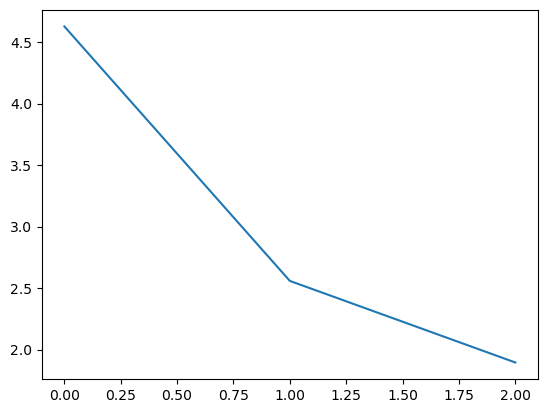

In [28]:
if b_unsup_pretrain:
    if b_reload_unsup_pretrain:
        trained_model_folder = 'runs/May23_13-59-28_i3t-server'
        state_dict = torch.load(trained_model_folder + "/pretrained_model.pkl", weights_only=False)
        pretrain_model.net.load_state_dict(state_dict)
    else:
        
        loss_log = pretrain_model.fit(
            pretrain_dataset,
            #n_epochs=50,
            #n_epochs=2,
            n_iters=600,#600,
            verbose=True
        )

        pretrain_model.save(writer.get_logdir() + "/pretrained_model.pkl")
        with open(writer.get_logdir() + "/pretrained_loss.txt", 'w') as f:
            for loss in loss_log:
                f.write(f"{loss}\n")

        plt.plot(loss_log)
        plt.show()


In [29]:
#pretrain_model.encode(pretrain_dataset[0:64]).shape

#### PSD Encoder self-supervised training

In [30]:
from models.DeepSEEModels import TimesformerConfig, TimesformerModel
from models.DeepSEEModels import PointDistProjection, MultiModalCrossAttentionConfig

In [31]:
# PD: Point distribution
config_PD = TimesformerConfig(image_size = 128,
                             patch_size = 8,
                             num_channels = 3,
                             num_frames = 4,
                             num_hidden_layers = 3,
                             num_attention_heads = 12,
                             hidden_size = 192,
                             intermediate_size = 256,
                             hidden_dropout_prob = 0)

config_CA = MultiModalCrossAttentionConfig(
                                        ts2vec_only = True,
                                        ts2vec_dim = 64,
                                        # Time Series
                                        ts_context_length = 30,
                                        ts_patch_len = 5,
                                        ts_num_input_channels = 64,
                                        ts_patch_stride = 5,
                                        ts_d_model = 192,
                                        ts_time_step = 33, 
                                        # PD parameter
                                        pd_d_model = 192,
                                        pd_time_step = 33*10,
                                        pe_max_len = 10000, 
                                        # CA
                                        ca_d_model = 128, 
                                        ca_num_head = 16,
                                        ca_num_layers = 2,
                                        ca_dropout = 0.0, 
                                        ca_time_series_only=False, 
                                        output_range=None
                                    )

In [32]:
class PSDSSL(torch.nn.Module):
    def __init__(self, pd_config: TimesformerConfig, config):
        super().__init__()        
        
        self.pd_config = pd_config
        
        # Encoder
        self.pd_encoder = TimesformerModel(pd_config)

        #self.pd_proj = PointDistProjection(config)

        self.fc1 = torch.nn.Linear(192, 192)
        self.fc2 = torch.nn.Linear(192, 192)

        
    def forward(self, point_dist):
        #x_pd = torch.rand((1, 4, 3, 96, 128))#
        # pd shape: ((Bs, 4, 3, 96, 128))#
        #                 4  : 12 * 16
        
        # Random Mask
        batch_size = point_dist.shape[0]
        binary_mask = torch.ones((batch_size, 4, 3, 12, 16), dtype=torch.float).to(point_dist.device)

        mask_indices = torch.randint(0, 4, (batch_size, 12, 16))#.to(point_dist.device)
        mask_indices1 = torch.randint(0, 4, (batch_size, 12, 16))#.to(point_dist.device)


        # Construct the mask
        for i in range(batch_size):
            for j in range(12):
                for k in range(16):
                    binary_mask[i, mask_indices[i,j,k], :, j, k] = 0
                    binary_mask[i, mask_indices1[i,j,k], :, j, k] = 0
        
        mask_indices = torch.randint(0, 4, (batch_size, 12, 16)).to(point_dist.device)

                    
        binary_mask = torch.nn.functional.interpolate(binary_mask, scale_factor=(1,8,8), mode="nearest")

        # Apply the mask
        masked_x_pd = point_dist * binary_mask

        pd_hs = self.pd_encoder(masked_x_pd).last_hidden_state
        #pd_hs = self.pd_proj(pd_hs)

        patch_height, patch_width, pd_num_frame = 12,16,4
        pd_d_model = self.pd_config.hidden_size

        # pd_hidden_state.shape
        # (batch_size, 1 + H//P * W//P * T, hidden_size)
        # Drop the [CLS] token in the front
        pd_hs = pd_hs[:,1:,:]
        # Time-preserved reshape
        #print("PD Projection Shape {}".format(hidden_state.shape))
        pd_hs = pd_hs.view(batch_size, 
                            patch_height, patch_width,
                            pd_num_frame, 
                            pd_d_model
                        ).reshape(
                            batch_size,
                            patch_height*patch_width, pd_num_frame, pd_d_model)
        # Shape (BS, 12*16, 4, 192)
        pd_hs = pd_hs.permute(0, 2, 1, 3)
        pd_hs = pd_hs.reshape(batch_size, pd_num_frame, patch_height*patch_width, pd_d_model)

        pd_hs = self.fc1(pd_hs)
        pd_hs = torch.nn.functional.gelu(pd_hs)
        pd_hs = self.fc2(pd_hs)

        pd_hs = pd_hs.view(batch_size, pd_num_frame, patch_height, patch_width, 3, 8, 8)
        pd_hs = pd_hs.permute(0, 1, 4, 2, 5, 3, 6) # (batch_size, pd_num_frame, 3, patch_height,8, patch_width, 8)
        
        y_pd = pd_hs.reshape(batch_size,4,3,96,128)
        
        return y_pd

In [33]:
psd_ssl_model = PSDSSL(config_PD, config_CA)

In [34]:
x_pd = torch.rand((5, 4, 3, 96, 128))#.to(device)

In [35]:
y_pd = psd_ssl_model.forward(x_pd)

In [36]:
from accelerate import Accelerator
from accelerate.utils import set_seed
from torch.optim import AdamW
from transformers import AutoModelForSequenceClassification, get_scheduler
from transformers import get_constant_schedule_with_warmup

In [37]:
def loss_fn(outputs, targets, device):
    return torch.nn.MSELoss()(outputs, targets)

In [38]:
def PSD_Pretrain(model, pretrain_loader):
    set_seed(config.seed)
    accelerator = Accelerator(mixed_precision="bf16")
    #accelerator.device = config.device
    #optimizer = AdamW(model.parameters(), lr=config.lr)
    optimizer = AdamW(model.parameters(), lr=1e-3)

    num_epochs = 30 #config.epochs
    num_training_steps = num_epochs * len(pretrain_loader)
    lr_scheduler = get_scheduler(
        "constant_with_warmup", #"linear", #"constant_with_warmup",
        optimizer=optimizer,
        num_warmup_steps= int(0.05*num_training_steps),
        num_training_steps=num_training_steps,
    )

    pretrain_dl, model, optimizer, lr_scheduler = accelerator.prepare(
        pretrain_loader,
        model, 
        optimizer,
        lr_scheduler
    )

    model = model.to(accelerator.device)

    progress_bar = tqdm(range(num_training_steps))
    epoch_loss = []

    for epoch in range(num_epochs):
        
        model.train()
        counter = 0
        train_loss_list = []
        for batch in pretrain_dl:
            point_dist = batch['point_dist'].to(accelerator.device, dtype = torch.float)

            outputs = model(point_dist)
            loss = loss_fn(point_dist, outputs, accelerator.device)
            train_loss_list.append(loss.item())

            # if(counter%10==0):
            #     print(f'Epoch: {epoch}, Iter: {counter}, Loss:  {np.mean(train_loss_list)}')

            accelerator.backward(loss)


            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad()
            counter += 1

            progress_bar.update(1)

        epoch_loss.append(np.mean(train_loss_list))
        print(f'Epoch: {epoch}, Loss:  {np.mean(train_loss_list)}')
    return model, epoch_loss

In [39]:
pretrain_params = {'batch_size': config.batchsize,
                'shuffle': True,
                'num_workers': 8
                }
pretrain_loader = DataLoader(unsup_pretrain_set, **pretrain_params)


In [40]:
# Pretain the PSD Encoder
if True:
    psd_ssl_model , epoch_loss = PSD_Pretrain(psd_ssl_model, pretrain_loader)
    # Save model
    torch.save(psd_ssl_model.pd_encoder.state_dict(), writer.get_logdir() + "/psd_ssl_model.pth")

  0%|          | 0/4680 [00:00<?, ?it/s]

Epoch: 0, Loss:  648.6728883400941
Epoch: 1, Loss:  543.1171454405173
Epoch: 2, Loss:  468.3476961576022
Epoch: 3, Loss:  418.7672641460712
Epoch: 4, Loss:  386.48658282940204
Epoch: 5, Loss:  361.61832212790466
Epoch: 6, Loss:  341.5883272611178
Epoch: 7, Loss:  325.950676551232
Epoch: 8, Loss:  313.63241498898236
Epoch: 9, Loss:  303.2222675421299
Epoch: 10, Loss:  295.97422184088293
Epoch: 11, Loss:  289.41164926382214
Epoch: 12, Loss:  283.9405924479167
Epoch: 13, Loss:  279.5444026849209
Epoch: 14, Loss:  275.4536686432667
Epoch: 15, Loss:  272.77447509765625
Epoch: 16, Loss:  270.5557215763972
Epoch: 17, Loss:  268.50805145654925
Epoch: 18, Loss:  266.4630350944323
Epoch: 19, Loss:  265.3664162464631
Epoch: 20, Loss:  264.7349078838642
Epoch: 21, Loss:  264.4735456613394
Epoch: 22, Loss:  263.5898111783541
Epoch: 23, Loss:  263.02094826331506
Epoch: 24, Loss:  262.448787689209
Epoch: 25, Loss:  261.71405733548676
Epoch: 26, Loss:  260.9184431418394
Epoch: 27, Loss:  260.159127064

# Supervised Pretraining
### Data Loader

In [41]:
len(sup_pretrain_train_set)

8375

In [42]:
len(sup_pretrain_val_set)

1189

In [43]:
len(sup_pretrain_test_set)

1147

# Model - Baseline

In [44]:
from sklearn.ensemble import RandomForestRegressor

In [45]:
def global_pooling_1D(features):
    mean_features = torch.mean(features, dim=0)
    return mean_features

In [46]:
# Remove the following internal SLAM features from X:
# matched inliers, ourliers, PrePOKeyMapLoss, avgMPDepth, VarMPDepth, LocalMappingError
#
#  ['Brightness','Contrast','Entropy','Laplacian', 
# 'AvgMPDepth','VarMPDepth','PrePOKeyMapLoss',\
# 'PostPOOutlier', 'MatchedInlier',\
# 'DX','DY','DZ','Yaw','Pitch','Roll',\
# 'local_visual_BA_Err']
# X_train shape torch.Size([2749, 16])
indices_to_remove = [4,5,6,7,8,15]
# Get all column indices
all_indices = torch.arange(16)
# Create a mask to keep columns not in indices_to_remove
mask = ~torch.tensor([i in indices_to_remove for i in all_indices])

def load_data_from_dataset(dataset):
    X = []
    Y = []
    for idx in range(len(dataset)):
        X.append(global_pooling_1D(dataset[idx]['time_series']).unsqueeze(dim=0))
        Y.append(dataset[idx]['relative_error'].unsqueeze(dim=0))

    X = torch.cat(tuple(X), dim=0)
    Y = torch.cat(tuple(Y), dim=0)

    X_select = X[:, mask]

    return X_select, Y

In [47]:
def ensemble_tree_data_loader(train_set, val_set, test_set):
    X_train, Y_train = load_data_from_dataset(train_set)
    X_val, Y_val = load_data_from_dataset(val_set)
    X_test, Y_test = load_data_from_dataset(test_set)
    return X_train, Y_train, X_val, Y_val, X_test, Y_test

# Model - DeepSEE

In [48]:
from models.DeepSEEModels import TimesformerConfig, PatchTSMixerConfig, MultiModalCrossAttentionConfig
from models.DeepSEEModels import DeepSEEModel

In [49]:
# PD: Point distribution
config_PD = TimesformerConfig(image_size = 128,
                             patch_size = 8,
                             num_channels = 3,
                             num_frames = 4,
                             num_hidden_layers = 3,
                             num_attention_heads = 12,
                             hidden_size = 192,
                             intermediate_size = 256,
                             #hidden_dropout_prob = 0.1)
                             hidden_dropout_prob = 0)

In [50]:
if b_unsup_pretrain:
    config_TS = PatchTSMixerConfig(context_length = 30, 
                                prediction_length = 1,
                                num_input_channels = 64, 
                                d_model = 192,
                                patch_len = 10,
                                patch_stride = 5,
                                use_positional_encoding = True,
                                ca_d_model = 128,
                                num_layers = 3,
                                drop_out = 0.0
                            )
else:
    config_TS = PatchTSMixerConfig(context_length = 30, 
                                prediction_length = 1,
                                num_input_channels = 16, 
                                d_model = 192,
                                patch_len = 10,
                                patch_stride = 5,
                                use_positional_encoding = True,
                                ca_d_model = 128,
                                num_layers = 3,
                                drop_out = 0.0
                            )

In [51]:
if b_unsup_pretrain:
    config_CA = MultiModalCrossAttentionConfig(
                                            ts2vec_only = True,
                                            ts2vec_dim = 64,
                                            # Time Series
                                            ts_context_length = 30,
                                            ts_patch_len = 5,
                                            #ts_num_input_channels = 16,
                                            ts_num_input_channels = 64,
                                            ts_patch_stride = 5,
                                            ts_d_model = 192,
                                            ts_time_step = 33, 
                                            # PD parameter
                                            pd_d_model = 192,
                                            pd_time_step = 33*10,
                                            pe_max_len = 10000, 
                                            # CA
                                            ca_d_model = 128, 
                                            ca_num_head = 16, 
                                            ca_num_layers = 2, 
                                            ca_dropout = 0.0, 
                                            ca_time_series_only=False, 
                                            output_range=None
                                        )
else:
    config_CA = MultiModalCrossAttentionConfig(ts_context_length = 30,
                                            ts_patch_len = 5,
                                            ts_num_input_channels = 16,
                                            #ts_num_input_channels = 64,
                                            ts_patch_stride = 5,
                                            ts_d_model = 192,
                                            ts_time_step = 33,
                                            # PD parameter
                                            pd_d_model = 192,
                                            pd_time_step = 33*10,
                                            pe_max_len = 10000, 
                                            # CA
                                            ca_d_model = 128, 
                                            ca_num_head = 16, 
                                            ca_num_layers = 2, 
                                            ca_dropout = 0.0, 
                                            ca_time_series_only=False, 
                                            output_range=None
                                        )

In [52]:
model = DeepSEEModel(config_PD, config_TS, config_CA)

In [53]:
# Load PSD Encoder weights
model.pd_encoder.load_state_dict(torch.load(writer.get_logdir() + "/psd_ssl_model.pth", weights_only=False))

<All keys matched successfully>

In [54]:
config_CA

MultiModalCrossAttentionConfig {
  "ca_d_model": 128,
  "ca_dropout": 0.0,
  "ca_num_head": 16,
  "ca_num_layers": 2,
  "ca_time_series_only": false,
  "output_range": null,
  "pd_d_model": 192,
  "pd_height": 128,
  "pd_num_frame": 4,
  "pd_patch_size": 8,
  "pd_time_step": 330,
  "pd_width": 96,
  "pe_max_len": 10000,
  "reg_d_fc": 128,
  "reg_dropout": 0.0,
  "transformers_version": "4.57.6",
  "ts2vec_dim": 64,
  "ts2vec_only": true,
  "ts_context_length": 30,
  "ts_d_model": 192,
  "ts_num_input_channels": 64,
  "ts_patch_len": 5,
  "ts_patch_stride": 5,
  "ts_time_step": 33
}

In [55]:
#model.compile()

In [56]:
%%timeit

# # dummy_TS
if b_unsup_pretrain:
    x_ts = torch.rand((1, 30, 64))###.to(device)
else:
    x_ts = torch.rand((1, 30, 16))###.to(device)
x_pd = torch.rand((1, 4, 3, 96, 128))#.to(device)
model(x_pd,x_ts)

19.5 ms ± 1.21 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


# Supervised Pretrain

In [57]:
from torchmetrics.regression import MeanAbsolutePercentageError
import numpy as np

In [58]:
optimizer = torch.optim.Adam(params = model.parameters(), lr=config.lr)

In [59]:
class WeightedMSELoss(torch.nn.Module):
    def __init__(self, alpha=1.0):
        """
        Initializes the WeightedMSELoss module.
        :param alpha: Controls the influence of the label value on the loss weighting.
        """
        super(WeightedMSELoss, self).__init__()
        self.alpha = alpha

    def forward(self, predictions, targets):
        """
        Computes the weighted MSE loss.
        :param predictions: The predicted values from the model.
        :param targets: The actual target values from the dataset.
        :return: The computed weighted MSE loss.
        """
        with torch.no_grad():
            weights = (1 + self.alpha * targets) ** 4  # Compute weights as the square of (1 + alpha * targets)
        loss = (predictions - targets) ** 2
        weighted_loss = weights * loss
        return torch.mean(weighted_loss)

In [60]:
def loss_fn(outputs, targets, device):
    return  MeanAbsolutePercentageError().to(device)(outputs,targets)*2 + torch.nn.MSELoss().to(device)(outputs, targets)
 

In [61]:
class SaveBestModel:
    """
    Class to save the best model while training. If the current epoch's 
    validation loss is less than the previous least less, then save the
    model state.
    """
    def __init__(
        self, best_valid_loss=float('inf')
    ):
        self.best_valid_loss = best_valid_loss
        
    def __call__(
        self, current_valid_loss, 
        epoch, model, optimizer, criterion, ouput_folder, file_name='best_model'
    ):
        if epoch >= 1:
            if current_valid_loss < self.best_valid_loss:
                self.best_valid_loss = current_valid_loss
                print(f"\nBest validation loss: {self.best_valid_loss}")
                print(f"\nSaving best model for epoch: {epoch+1}\n")
                torch.save({
                    'epoch': epoch+1,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss': criterion,
                    }, '{}/{}.pth'.format(ouput_folder, file_name))


def save_model(epochs, model, optimizer, criterion, output_folder, file_name='final_model'):
    """
    Function to save the trained model to disk.
    """
    print(f"Saving final model...")
    torch.save({
                'epoch': epochs,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': criterion,
                }, '{}/{}.pth'.format(output_folder, file_name))

In [62]:
from accelerate import Accelerator
from accelerate.utils import set_seed
from torch.optim import AdamW
from transformers import AutoModelForSequenceClassification, get_scheduler

In [63]:
def train_with_validation(model, train_loader, val_loader, test_loader, config, mode="SupervisedPretrain"):
    set_seed(config.seed)
    accelerator = Accelerator(mixed_precision="bf16")
    optimizer = AdamW(model.parameters(), lr=config.lr)

    num_epochs = config.epochs
    num_training_steps = num_epochs * len(train_loader)
    lr_scheduler = get_scheduler(
        "constant_with_warmup",#"linear",
        optimizer=optimizer,
        num_warmup_steps= int(0.1*num_training_steps),
        num_training_steps=num_training_steps,
    )

    train_dl, val_dl, test_dl, model, optimizer, lr_scheduler = accelerator.prepare(
        train_loader, val_loader, test_loader,
        model, 
        optimizer,
        lr_scheduler
    )

    model = model.to(accelerator.device)

    for param in model.pd_encoder.parameters():
        param.requires_grad = False

    # initialize SaveBestModel class
    save_best_model = SaveBestModel()

    progress_bar = tqdm(range(num_training_steps))

    for epoch in range(num_epochs):
        
        model.train()
        counter = 0
        train_loss_list = []
        for batch in train_dl:
            if b_unsup_pretrain:
                time_series = pretrain_model.encode(batch['time_series'].cpu().numpy(), causal=True, sliding_length=1, sliding_padding=5)
                time_series = torch.from_numpy(time_series).to(accelerator.device, dtype = torch.float)
            else:
                time_series = batch['time_series'].to(accelerator.device, dtype = torch.float)
            
            point_dist = batch['point_dist'].to(accelerator.device, dtype = torch.float)
            relative_error = batch['relative_error'].to(accelerator.device, dtype = torch.float)

            outputs = model(point_dist, time_series)
            loss = loss_fn(outputs, relative_error, accelerator.device)
            train_loss_list.append(loss.item())

            # if(counter%10==0):
            #     print(f'Epoch: {epoch}, Iter: {counter}, Loss:  {np.mean(train_loss_list)}')

            # ...log the running loss
            writer.add_scalar(f'{mode} training loss', loss, epoch * len(train_dl) + counter)

            accelerator.backward(loss)

            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad()
            counter += 1

            progress_bar.update(1)

        writer.add_scalar(f'{mode} training epoch loss', np.mean(train_loss_list), epoch)


        model.eval()
        counter = 0
        val_loss_list = []
        for batch in val_dl:
            if b_unsup_pretrain:
                time_series = pretrain_model.encode(batch['time_series'].cpu().numpy(), causal=True, sliding_length=1, sliding_padding=5)
                time_series = torch.from_numpy(time_series).to(accelerator.device, dtype = torch.float)
            else:
                time_series = batch['time_series'].to(accelerator.device, dtype = torch.float)
            
            point_dist = batch['point_dist'].to(accelerator.device, dtype = torch.float)
            relative_error = batch['relative_error'].to(accelerator.device, dtype = torch.float)

            with torch.no_grad():
                outputs = model(point_dist, time_series)
                all_outputs, all_relative_errors = accelerator.gather_for_metrics((outputs, relative_error))
                loss = loss_fn(all_outputs, all_relative_errors, accelerator.device)
                val_loss_list.append(loss.item())
                # ...log the running loss
                writer.add_scalar(f'{mode} validation loss', loss, epoch * len(val_dl) + counter)
            counter += 1

        val_epoch_loss = np.mean(val_loss_list)
        writer.add_scalar(f'{mode} validation epoch loss', val_epoch_loss, epoch)
        save_best_model(
            val_epoch_loss, epoch, model, optimizer, loss_fn, writer.get_logdir(), f"{mode}_best_model"
        )

    # save the trained model weights for a final time
    save_model(num_epochs, model, optimizer, loss_fn, writer.get_logdir()), f"{mode}_final_model"

    return model



In [64]:
train_params = {'batch_size': config.batchsize,
                'shuffle': True,
                'num_workers': 8
                }

val_params = {'batch_size': config.batchsize,
                'shuffle': True,
                'num_workers': 8
                }

test_params = {'batch_size': config.batchsize,
                'shuffle': False,
                'num_workers': 8
                }

In [65]:
train_loader = DataLoader(sup_pretrain_train_set, **train_params)
val_loader = DataLoader(sup_pretrain_val_set, **val_params)
test_loader = DataLoader(sup_pretrain_test_set, **test_params)

In [66]:
config.epochs=2

In [67]:
model = train_with_validation(model, train_loader, val_loader, test_loader, config, mode="SupervisedPretrain")

  0%|          | 0/132 [00:00<?, ?it/s]


Best validation loss: 5.936330509185791

Saving best model for epoch: 2

Saving final model...


# Supervised Pretrain Evaluation

In [68]:
import torch
import matplotlib.pyplot as plt

In [69]:
from sklearn.metrics import mean_absolute_percentage_error

In [70]:
def get_mse(y_gt,y_est):
    assert(y_gt.shape == y_est.shape)
    return np.mean((y_gt - y_est) ** 2)

def get_mape(y_gt,y_est):
    assert(y_gt.shape == y_est.shape)
    return mean_absolute_percentage_error(y_gt, y_est)

In [71]:
from scipy.ndimage import uniform_filter

In [72]:

def plot_result_on_testset(Y_gt, Y_est, YT_test_head=None, mode="SupervisedPretrain", target_transform=False):
    # Concatenate tensors along the specified dimension (0 for row-wise concatenation)
    Y_gt_np = torch.cat(Y_gt, dim=0).cpu().numpy()
    Y_est_np = torch.cat(Y_est, dim=0).cpu().numpy()

    np.save(writer.get_logdir()+f"/{mode}_Y_gt.npy", Y_gt_np)
    np.save(writer.get_logdir()+f"/{mode}_Y_est.npy", Y_est_np)

    if target_transform:
        Y_gt_np = (np.exp(Y_gt_np)-1)/10000
        Y_est_np = (np.exp(Y_est_np)-1)/10000
    
    # Plotting
    plt.figure(figsize=(20,5))

    plt.plot(Y_gt_np, c='g', alpha=0.75, label="GT")
    plt.plot(Y_est_np, c='b', alpha=0.5, label="DeepSEE")
    
    if YT_test_head is not None:
        Y_base_np = np.expand_dims(YT_test_head, axis=1)
        np.save(writer.get_logdir()+f"/{mode}_Y_base.npy", Y_base_np)
        if target_transform:
            Y_base_np = (np.exp(Y_base_np)-1)/10000
        plt.plot(Y_base_np, c='r', alpha=0.25, label="Base")

    plt.xlabel('Index')
    plt.ylabel('Value')
    if YT_test_head is not None:
        plt.title('Pose Error Estimatioin on Test Set - DeepSEE MSE: {:.6f} MAPE: {:.6f} - Baseline MSE: {:.6f} MAPE: {:.6f}'.format(get_mse(Y_gt_np,Y_est_np), 
                                                                                                                                     get_mape(Y_gt_np,Y_est_np),
                                                                                                                                     get_mse(Y_gt_np, Y_base_np),
                                                                                                                                     get_mape(Y_gt_np,Y_base_np)))
    else:
        plt.title('Pose Error Estimatioin on Test Set - DeepSEE MSE: {:.6f}  MAPE: {:.6f}'.format(get_mse(Y_gt_np,Y_est_np), get_mape(Y_gt_np,Y_est_np)))
    plt.grid(True)
    plt.legend()
    #writer.add_figure("On testset", plt.gcf(),0)
    plt.savefig(writer.get_logdir()+f"/{mode}_Evaluation.png")
    plt.show()

In [73]:
# load the best model checkpoint
best_model_cp = torch.load('{}/SupervisedPretrain_best_model.pth'.format(writer.get_logdir()), weights_only=False)
best_model_epoch = best_model_cp['epoch']
model.load_state_dict(best_model_cp['model_state_dict'])
print(f"Best Supervised Pretrained model was saved at {best_model_epoch} epochs\n")

Best Supervised Pretrained model was saved at 2 epochs



In [74]:
def evaluate_on_test(model, test_loader, YT_test_head=None, mode="SupervisePretrain"):
    set_seed(config.seed)
    accelerator = Accelerator(mixed_precision="bf16")
    model, test_dl  = accelerator.prepare(model, test_loader)
    model.eval()
    counter = 0

    Y_gt = []
    Y_est = []

    for batch in test_dl:
        if b_unsup_pretrain:
            time_series = pretrain_model.encode(batch['time_series'].cpu().numpy(), causal=True, sliding_length=1, sliding_padding=5)
            time_series = torch.from_numpy(time_series).to(accelerator.device, dtype = torch.float)
        else:
            time_series = batch['time_series'].to(accelerator.device, dtype = torch.float)
        point_dist = batch['point_dist'].to(accelerator.device, dtype = torch.float)
        relative_error = batch['relative_error'].to(accelerator.device, dtype = torch.float)

        test_loss_list = []
        with torch.no_grad():
            outputs = model(point_dist, time_series)
            all_outputs, all_relative_errors = accelerator.gather_for_metrics((outputs, relative_error))
            loss = loss_fn(all_outputs, all_relative_errors, accelerator.device)
            test_loss_list.append(loss.item())

            Y_gt.append(relative_error)
            Y_est.append(outputs)

            # ...log the running loss
            writer.add_scalar(f'{mode} test loss', loss, counter)
            counter += 1

    print("Loss value on test set: {}".format(np.mean(test_loss_list)))

    if mode == "SupervisePretrain":
        plot_result_on_testset(Y_gt, Y_est, YT_test_head=None, mode=mode)
        return Y_gt, Y_est, None
    else:
        if YT_test_head is not None:
            plot_result_on_testset(Y_gt, Y_est, YT_test_head, mode=mode)
            return Y_gt, Y_est, YT_test_head
        else:
            plot_result_on_testset(Y_gt, Y_est, YT_test_head=None, mode=mode)
            return Y_gt, Y_est, None

    


Loss value on test set: 8.143807411193848


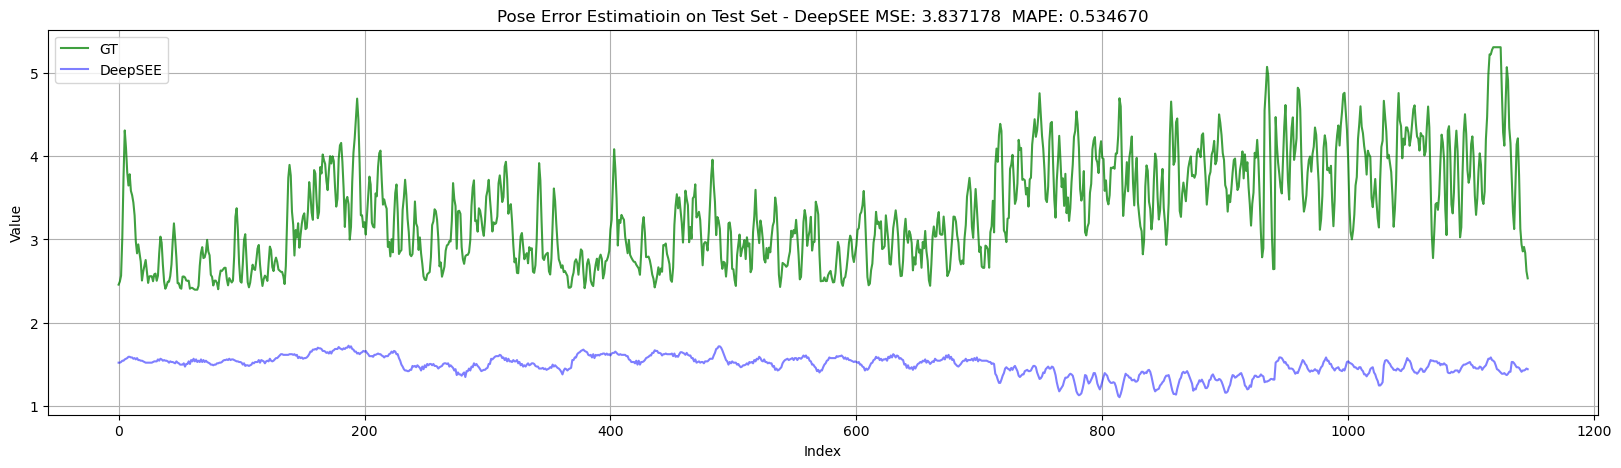

In [75]:
SupervisePretrain_Y_gt, SupervisePretrain_Y_est, _ = evaluate_on_test(model, test_loader, mode="SupervisePretrain")

In [76]:
#writer.close()

In [77]:
#sup_pretrain_train_data

# Supervised Finetuning

In [78]:
import random

def generate_random_sets(sample_number):
    groups = [['A2','A4','A7'],
                ['A3','A6','B3','B4','B5','B6','B7'],
                ['A5','B0','B1','B2']]

    finetune_split_config_list = []
    for idx in range(sample_number):
        val_list = []
        test_list = []
        train_list = []
        for group in groups:
            samples = random.sample(group, 2)
            val_list.append(samples[0])
            test_list.append(samples[1])
            train_list += [item for item in group if item not in samples]
        split_config = {
                        "sup_finetune_train_traj": {
                            "SenseTime": train_list
                        },
                        "sup_finetune_val_traj": {
                            "SenseTime": val_list
                        },
                        "sup_finetune_test_traj": {
                            "SenseTime": test_list
                        }
                    }
        finetune_split_config_list.append(split_config)
    return finetune_split_config_list


In [79]:
#generate_random_sets(10)

In [80]:
finetune_split_config_list = [
 {'sup_finetune_train_traj': {'SenseTime': ['A7',
    'A3',
    'A6',
    'B3',
    'B4',
    'B7',
    'B0',
    'B2']},
  'sup_finetune_val_traj': {'SenseTime': ['A4', 'B6', 'B1']},
  'sup_finetune_test_traj': {'SenseTime': ['A2', 'B5', 'A5']}},
 {'sup_finetune_train_traj': {'SenseTime': ['A2',
    'A3',
    'A6',
    'B3',
    'B4',
    'B5',
    'A5',
    'B0']},
  'sup_finetune_val_traj': {'SenseTime': ['A7', 'B7', 'B1']},
  'sup_finetune_test_traj': {'SenseTime': ['A4', 'B6', 'B2']}},
 {'sup_finetune_train_traj': {'SenseTime': ['A2',
    'A6',
    'B3',
    'B4',
    'B6',
    'B7',
    'A5',
    'B2']},
  'sup_finetune_val_traj': {'SenseTime': ['A7', 'B5', 'B0']},
  'sup_finetune_test_traj': {'SenseTime': ['A4', 'A3', 'B1']}},
 {'sup_finetune_train_traj': {'SenseTime': ['A7',
    'A6',
    'B4',
    'B5',
    'B6',
    'B7',
    'A5',
    'B1']},
  'sup_finetune_val_traj': {'SenseTime': ['A2', 'A3', 'B2']},
  'sup_finetune_test_traj': {'SenseTime': ['A4', 'B3', 'B0']}},
 {'sup_finetune_train_traj': {'SenseTime': ['A4',
    'A3',
    'A6',
    'B4',
    'B5',
    'B6',
    'A5',
    'B1']},
  'sup_finetune_val_traj': {'SenseTime': ['A2', 'B7', 'B2']},
  'sup_finetune_test_traj': {'SenseTime': ['A7', 'B3', 'B0']}},
 {'sup_finetune_train_traj': {'SenseTime': ['A4',
    'A6',
    'B3',
    'B4',
    'B5',
    'B6',
    'A5',
    'B0']},
  'sup_finetune_val_traj': {'SenseTime': ['A2', 'B7', 'B1']},
  'sup_finetune_test_traj': {'SenseTime': ['A7', 'A3', 'B2']}}]

In [81]:
y_pd.shape # torch.Size([5, 769, DIM])

torch.Size([5, 4, 3, 96, 128])

In [82]:
def MergeDict(dict1, dict2):
    res = {**dict1, **dict2}
    return res

load the best pretrained model



/home/junhyun/miniconda3/envs/deepsee/lib/python3.9/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


  0%|          | 0/580 [00:00<?, ?it/s]


Best validation loss: 3.5026174713583553

Saving best model for epoch: 2


Best validation loss: 2.4024714582106648

Saving best model for epoch: 3


Best validation loss: 1.7354941368103027

Saving best model for epoch: 4


Best validation loss: 1.3826361508930431

Saving best model for epoch: 5


Best validation loss: 1.2030705301200642

Saving best model for epoch: 6


Best validation loss: 1.1023290665710674

Saving best model for epoch: 7


Best validation loss: 1.0400294486214132

Saving best model for epoch: 8


Best validation loss: 0.9923647046089172

Saving best model for epoch: 9


Best validation loss: 0.9569561937276054

Saving best model for epoch: 10

Saving final model...
Best Supervised Finetuned model was saved at 10 epochs

Loss value on test set: 0.6795377135276794


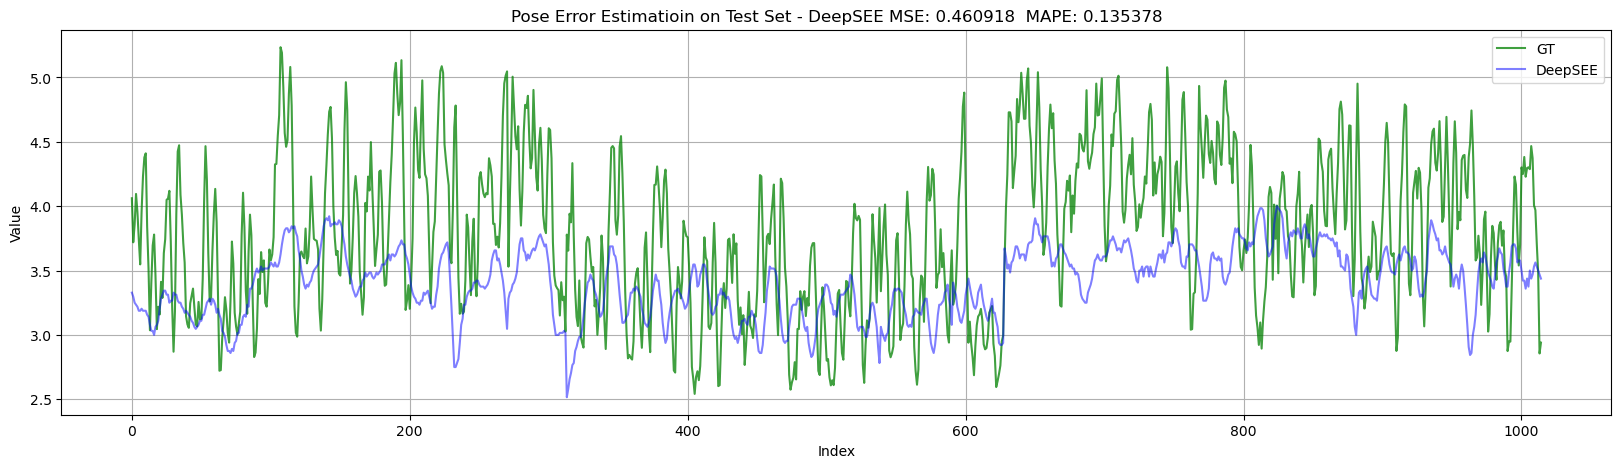

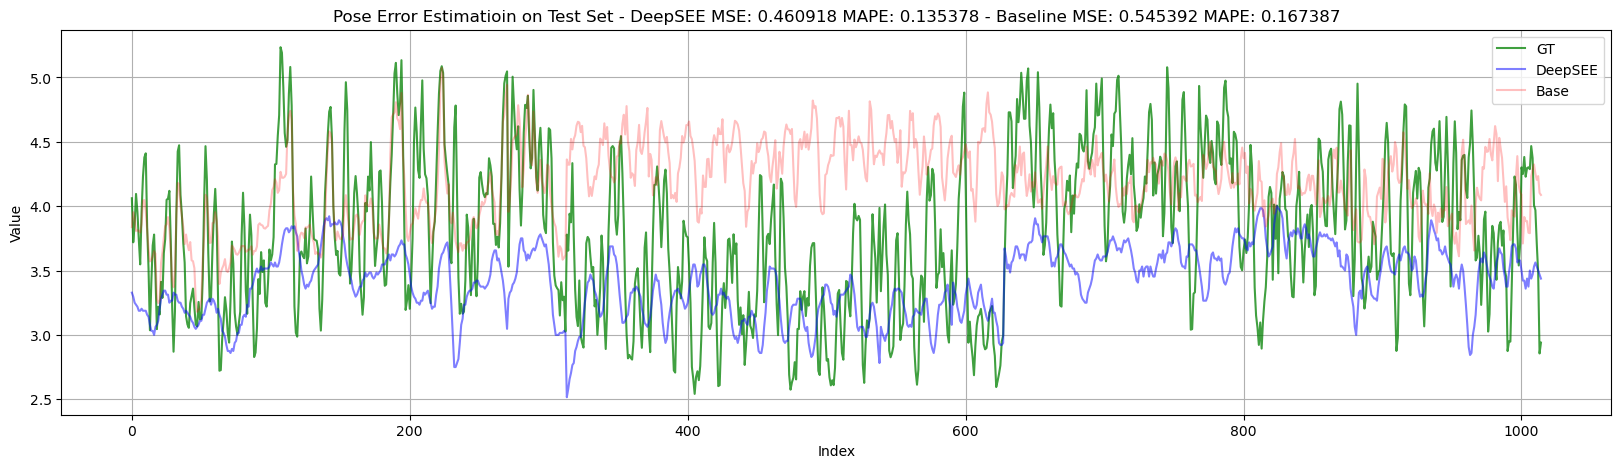

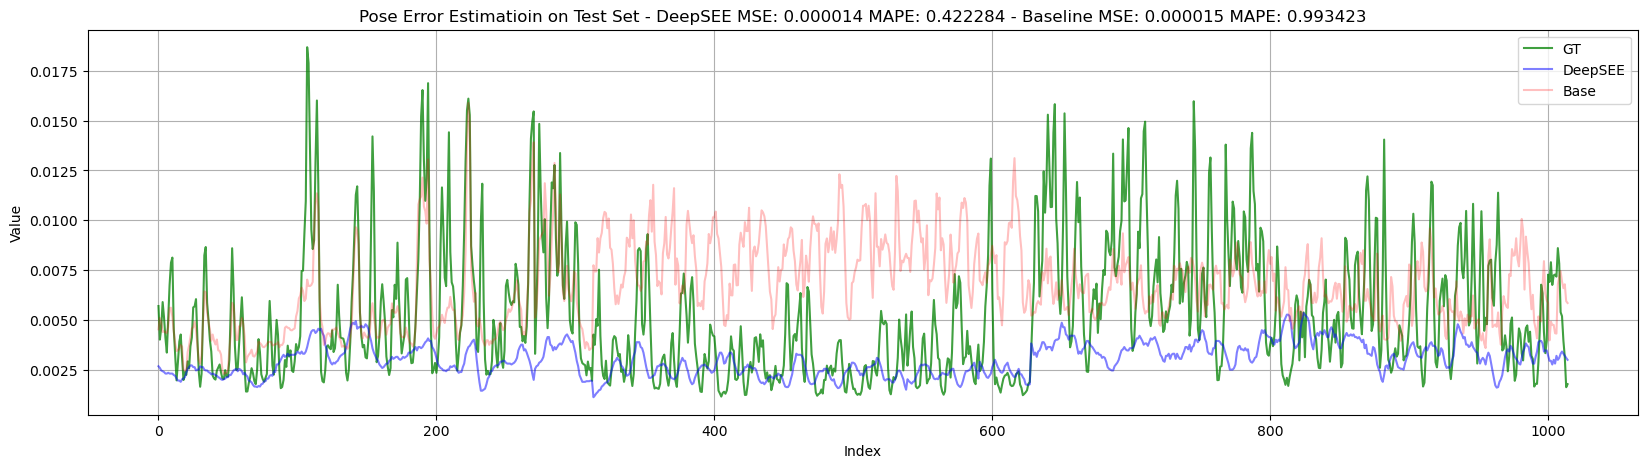

load the best pretrained model



/home/junhyun/miniconda3/envs/deepsee/lib/python3.9/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


  0%|          | 0/690 [00:00<?, ?it/s]


Best validation loss: 2.3188264863244417

Saving best model for epoch: 2


Best validation loss: 1.3263184613194958

Saving best model for epoch: 3


Best validation loss: 0.9543519307827127

Saving best model for epoch: 4


Best validation loss: 0.8832603487475165

Saving best model for epoch: 5


Best validation loss: 0.8769207329585634

Saving best model for epoch: 6


Best validation loss: 0.8646944987362829

Saving best model for epoch: 7


Best validation loss: 0.8382670591617453

Saving best model for epoch: 8


Best validation loss: 0.8144339261383846

Saving best model for epoch: 9


Best validation loss: 0.7920153634301548

Saving best model for epoch: 10

Saving final model...
Best Supervised Finetuned model was saved at 10 epochs

Loss value on test set: 0.6266660094261169


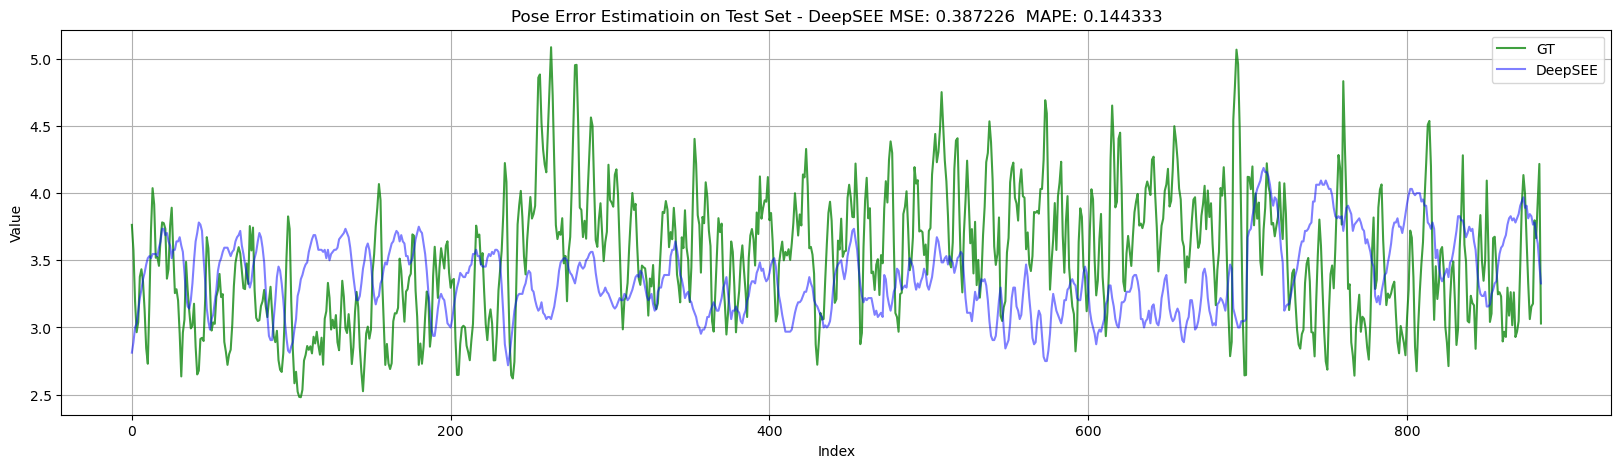

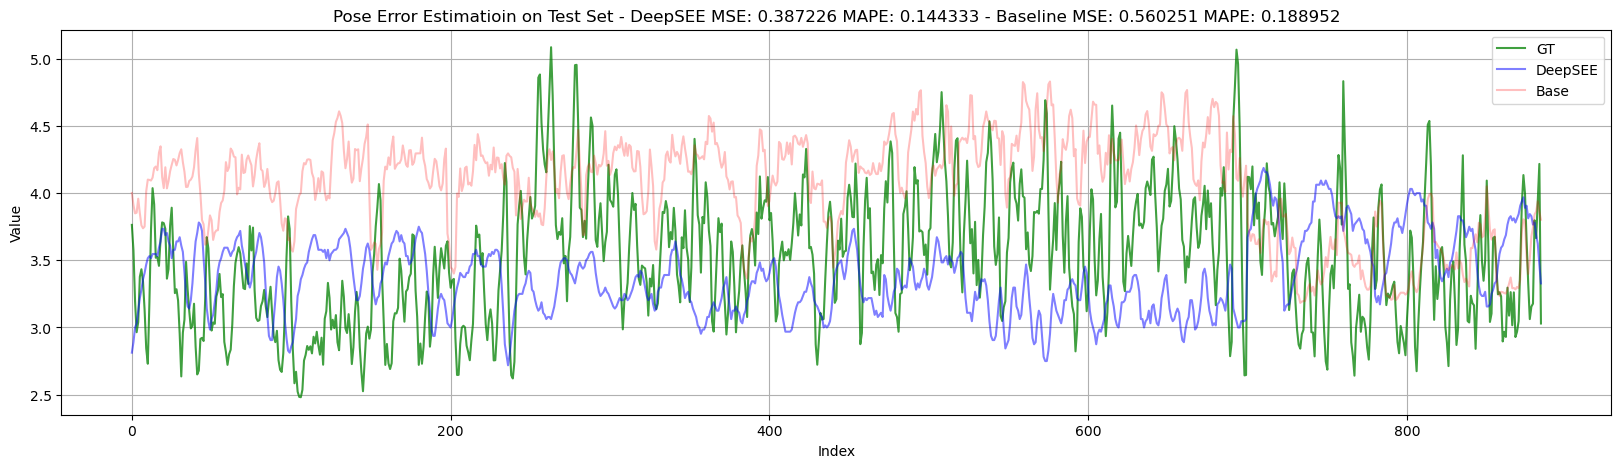

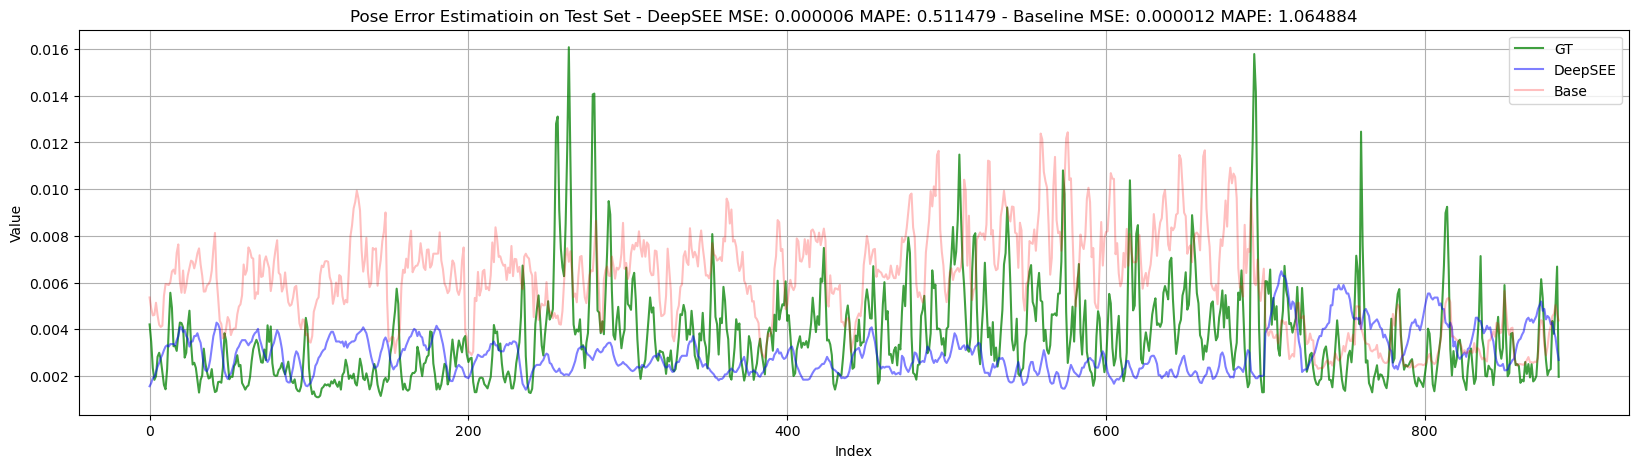

load the best pretrained model



/home/junhyun/miniconda3/envs/deepsee/lib/python3.9/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


  0%|          | 0/710 [00:00<?, ?it/s]


Best validation loss: 1.8209556426320757

Saving best model for epoch: 2


Best validation loss: 0.9237510774816785

Saving best model for epoch: 3


Best validation loss: 0.6562010454280036

Saving best model for epoch: 4

Saving final model...
Best Supervised Finetuned model was saved at 4 epochs

Loss value on test set: 0.6051911115646362


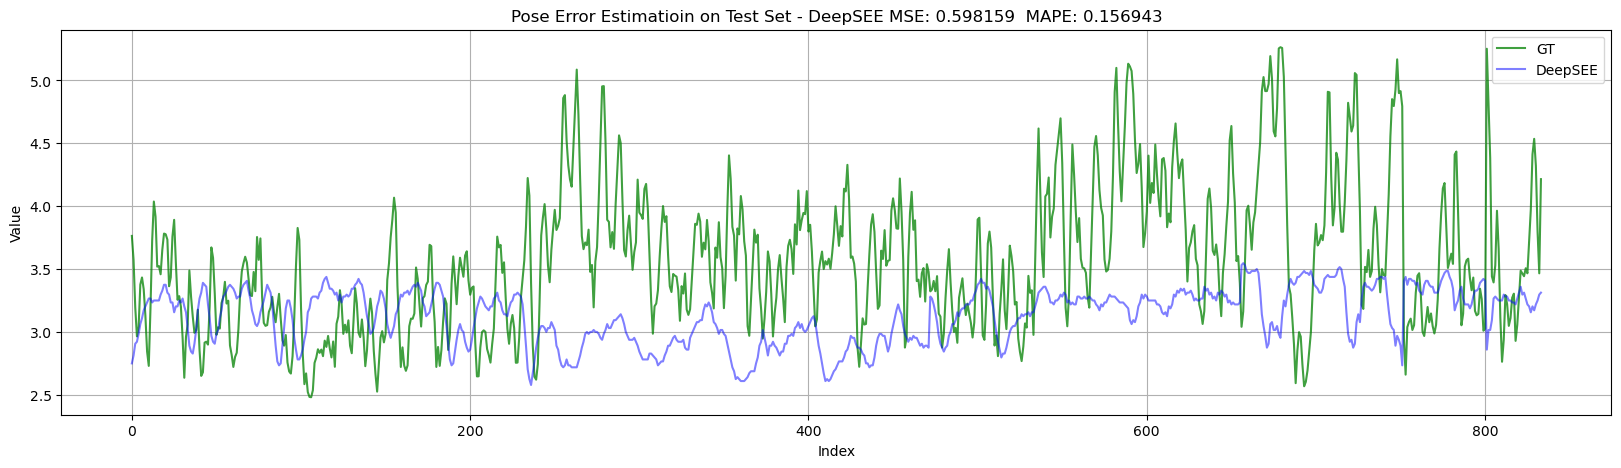

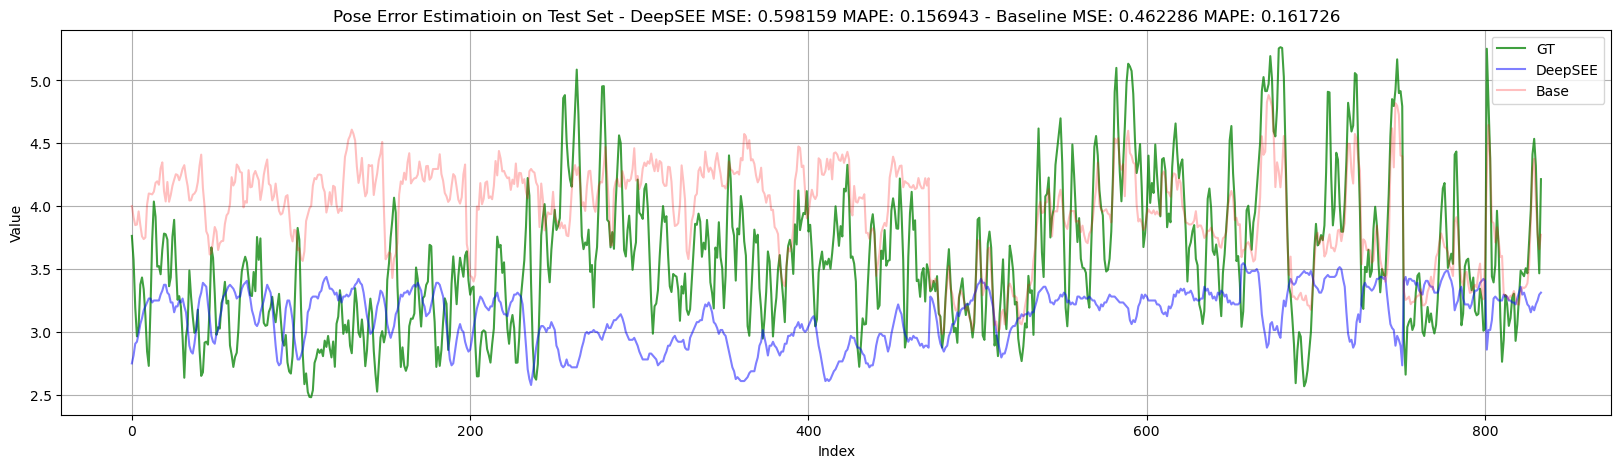

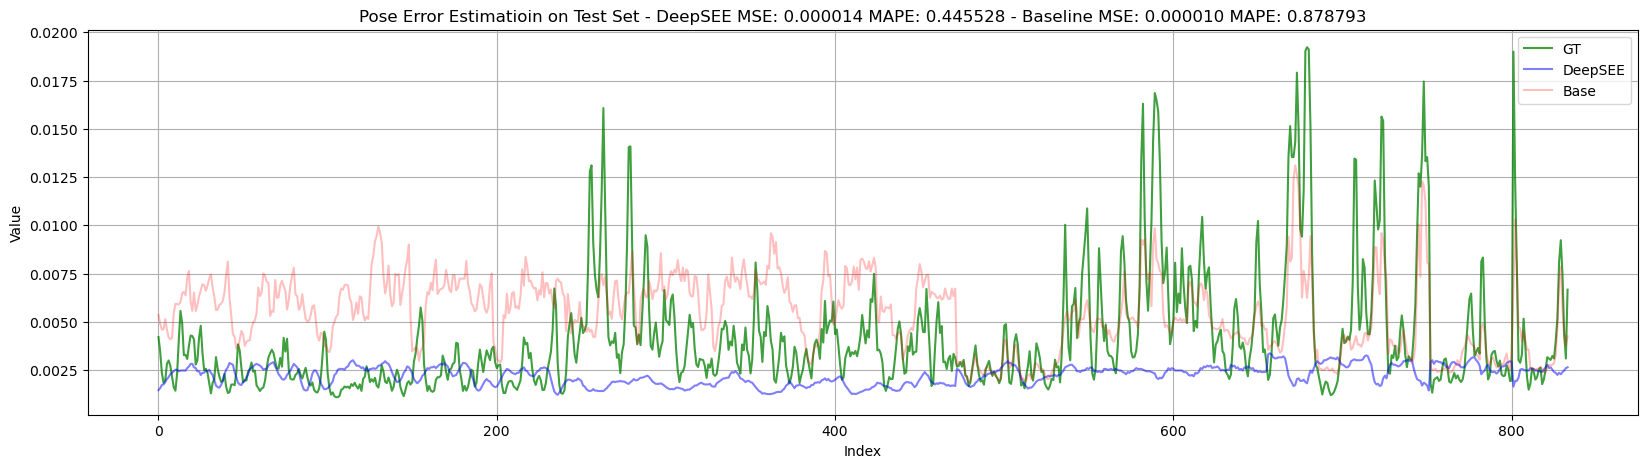

load the best pretrained model



/home/junhyun/miniconda3/envs/deepsee/lib/python3.9/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


  0%|          | 0/800 [00:00<?, ?it/s]


Best validation loss: 2.3773042360941568

Saving best model for epoch: 2


Best validation loss: 1.2434140178892348

Saving best model for epoch: 3


Best validation loss: 0.8088779957206161

Saving best model for epoch: 4


Best validation loss: 0.6869717041651408

Saving best model for epoch: 5


Best validation loss: 0.6735360070511147

Saving best model for epoch: 6

Saving final model...
Best Supervised Finetuned model was saved at 6 epochs

Loss value on test set: 1.4906479120254517


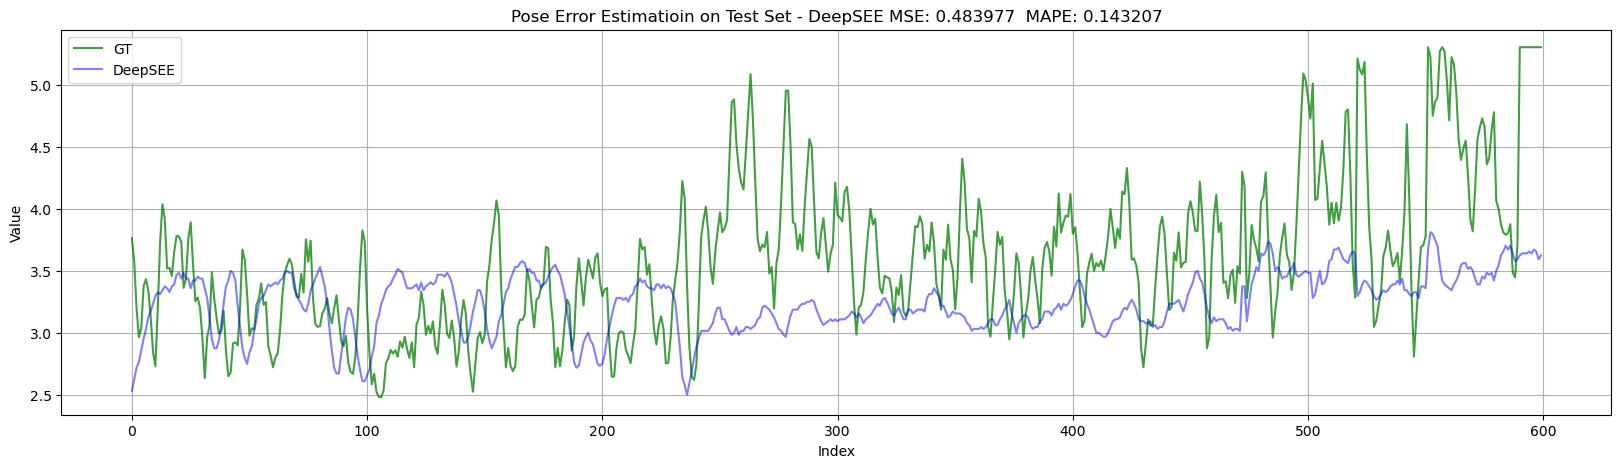

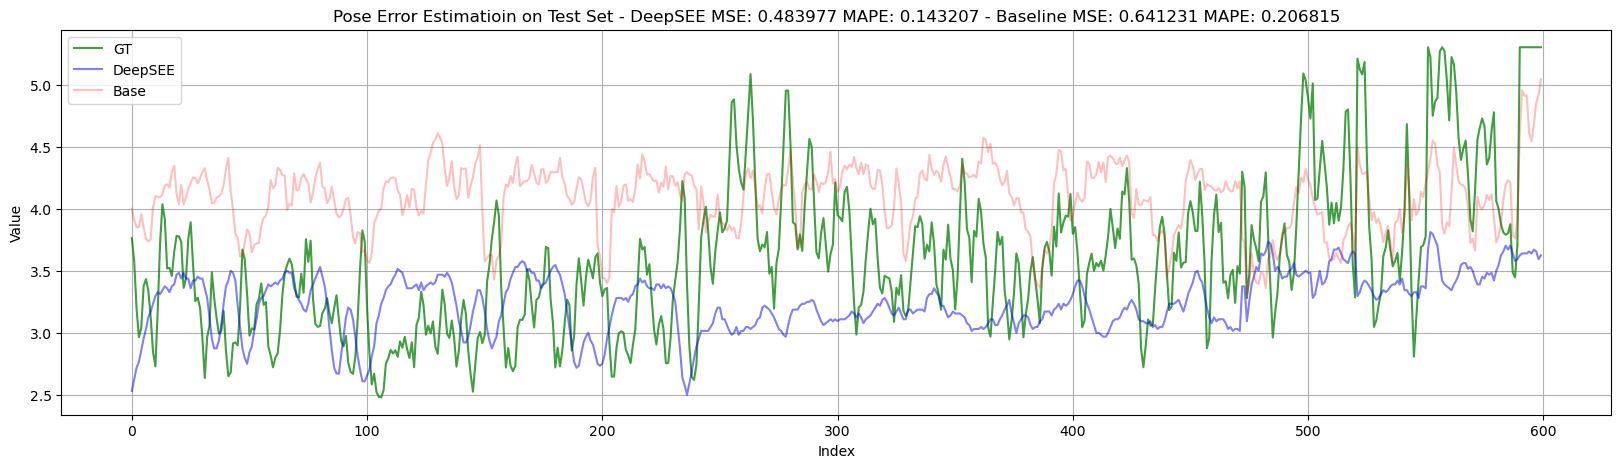

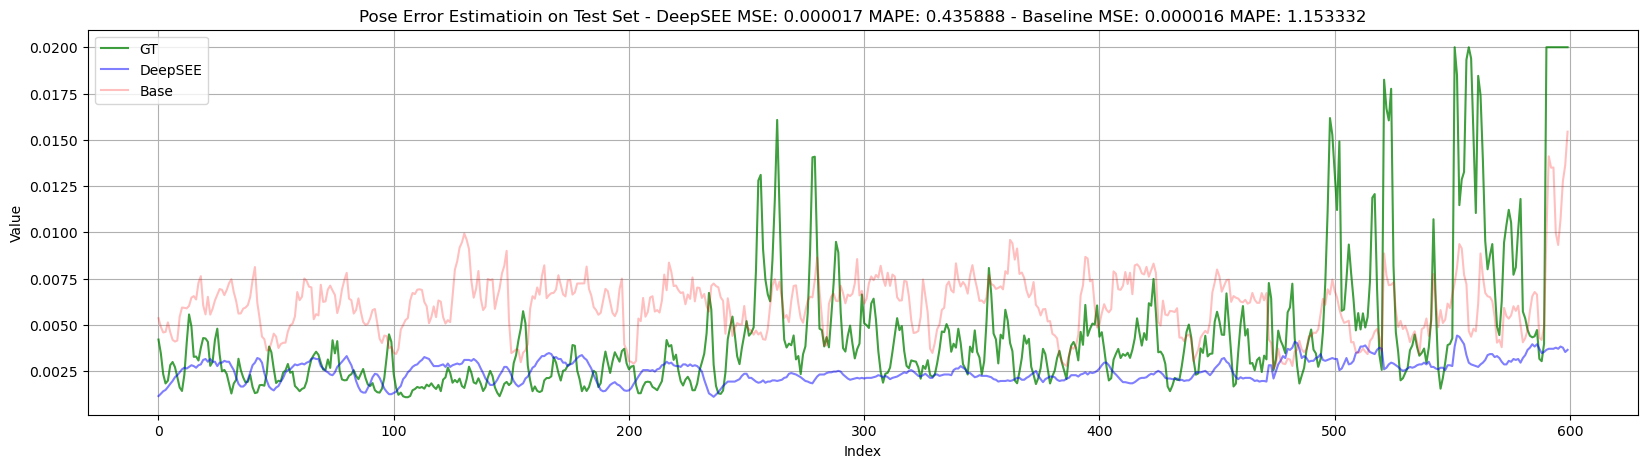

load the best pretrained model



/home/junhyun/miniconda3/envs/deepsee/lib/python3.9/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


  0%|          | 0/840 [00:00<?, ?it/s]


Best validation loss: 2.652321934700012

Saving best model for epoch: 2


Best validation loss: 1.3985615032059806

Saving best model for epoch: 3


Best validation loss: 0.8960367611476353

Saving best model for epoch: 4


Best validation loss: 0.7523046859673092

Saving best model for epoch: 5


Best validation loss: 0.7163950566734586

Saving best model for epoch: 6


Best validation loss: 0.7109978582177844

Saving best model for epoch: 7

Saving final model...
Best Supervised Finetuned model was saved at 7 epochs

Loss value on test set: 1.3525196313858032


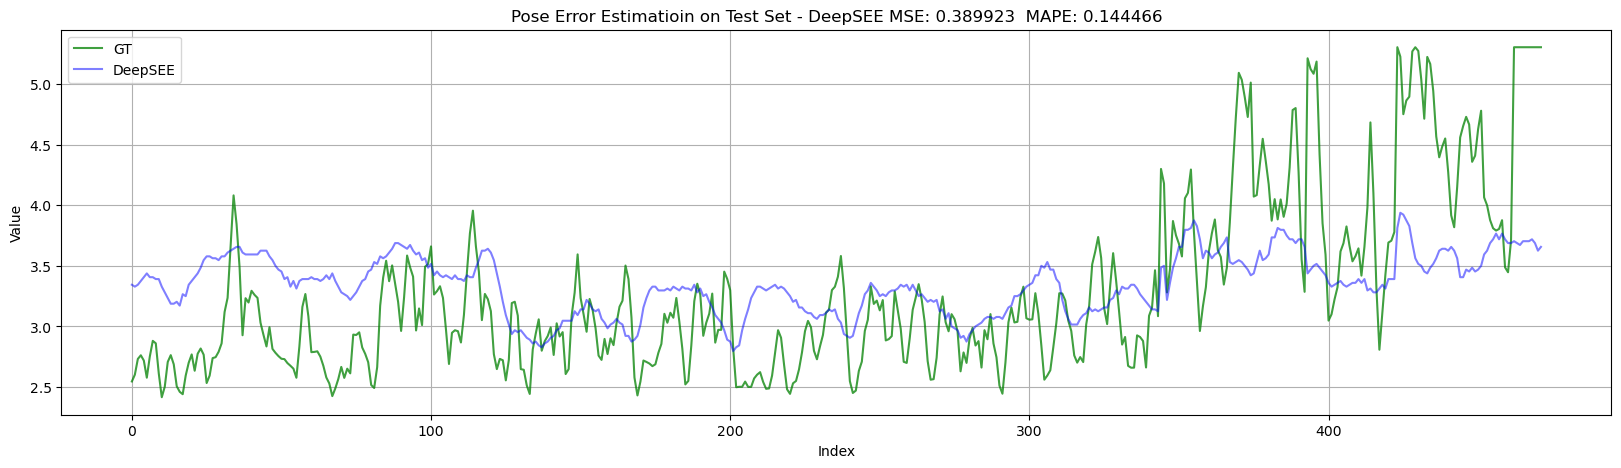

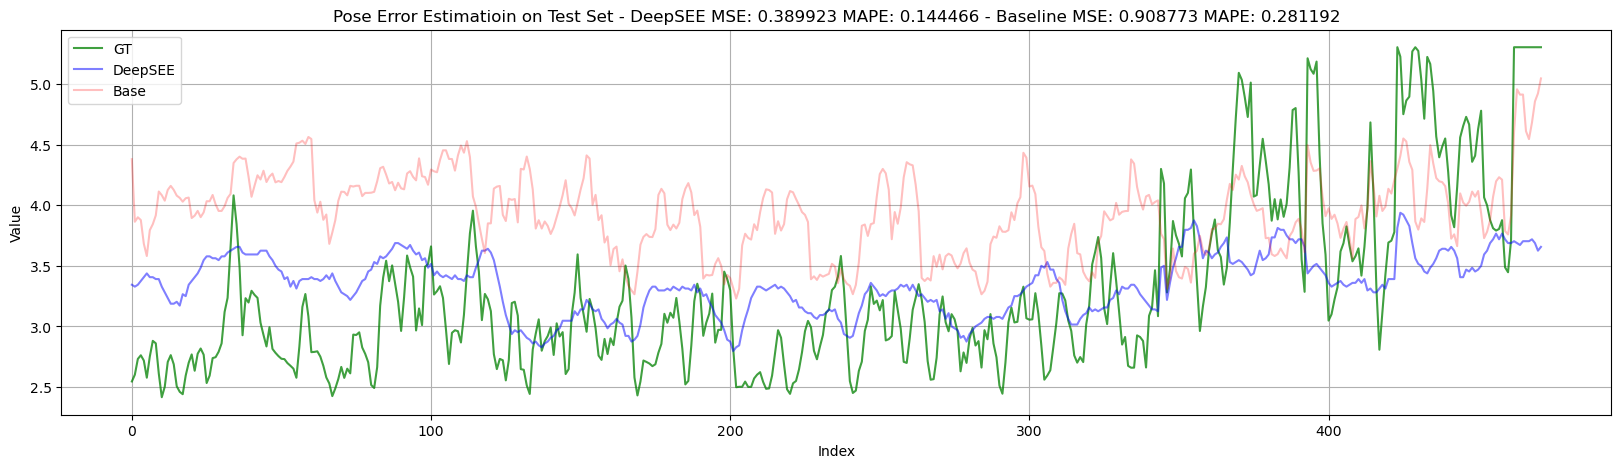

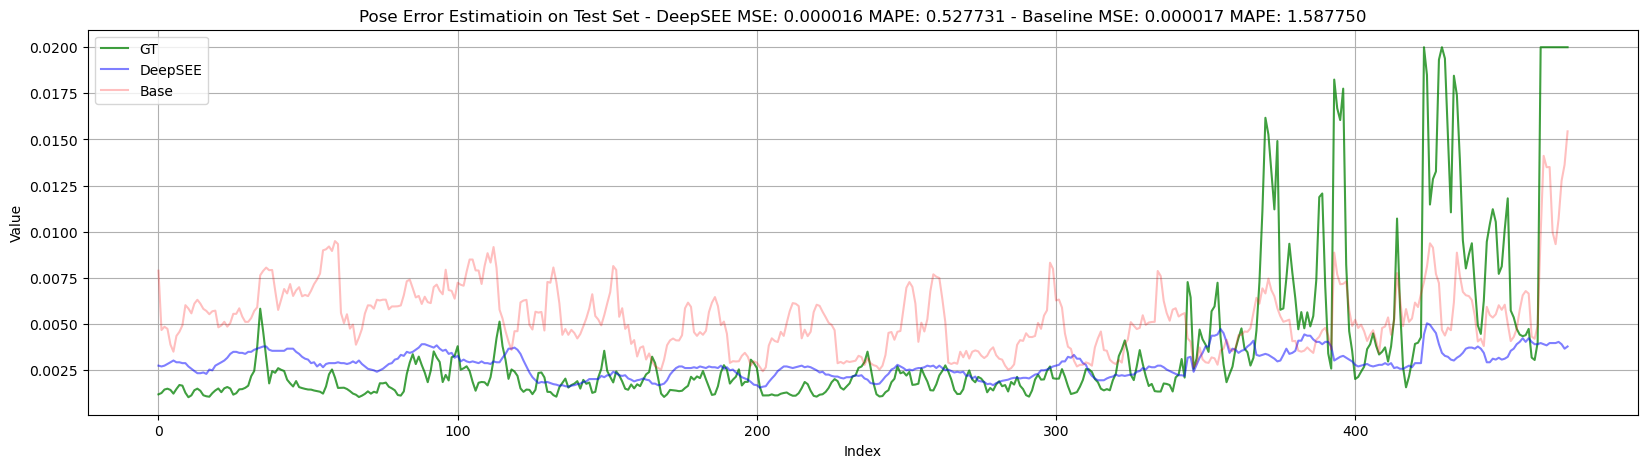

load the best pretrained model



/home/junhyun/miniconda3/envs/deepsee/lib/python3.9/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


  0%|          | 0/760 [00:00<?, ?it/s]


Best validation loss: 3.247632588659014

Saving best model for epoch: 2


Best validation loss: 1.8454327540738242

Saving best model for epoch: 3


Best validation loss: 1.168168108378138

Saving best model for epoch: 4


Best validation loss: 0.9037604289395469

Saving best model for epoch: 5


Best validation loss: 0.8185968909944806

Saving best model for epoch: 6


Best validation loss: 0.7961293054478509

Saving best model for epoch: 7

Saving final model...
Best Supervised Finetuned model was saved at 7 epochs

Loss value on test set: 0.4609108567237854


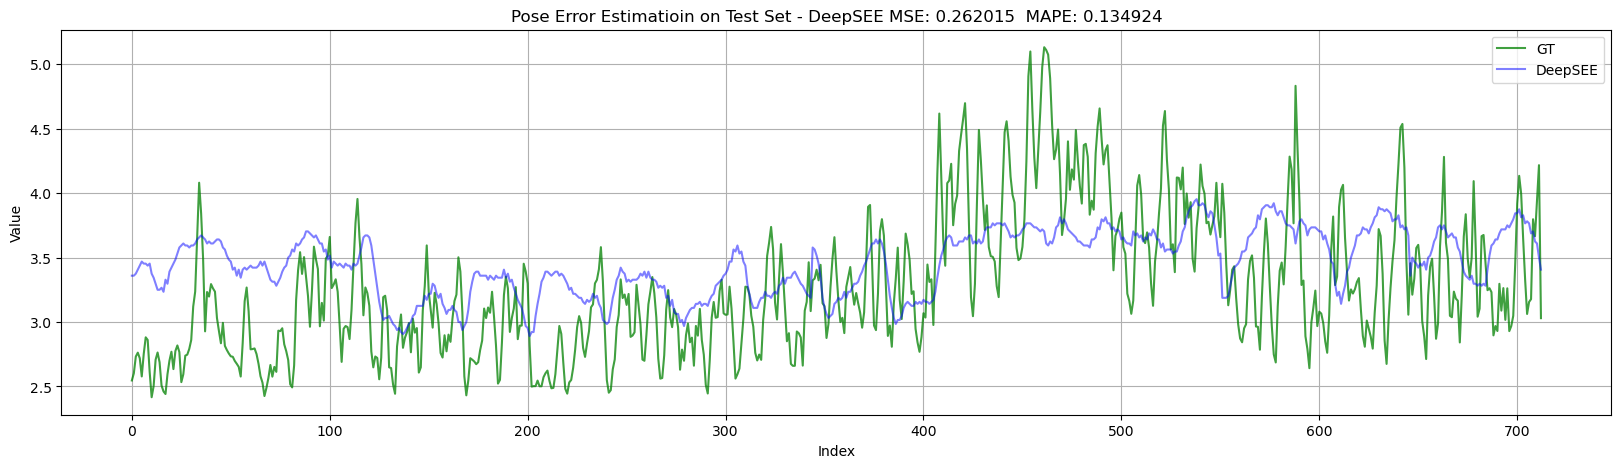

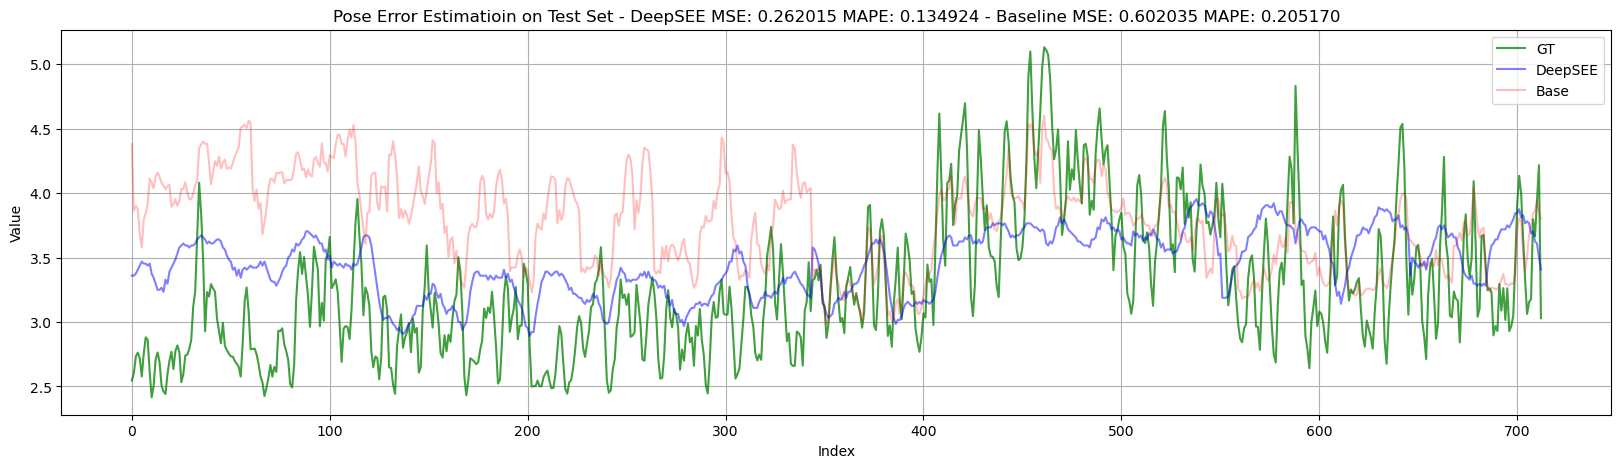

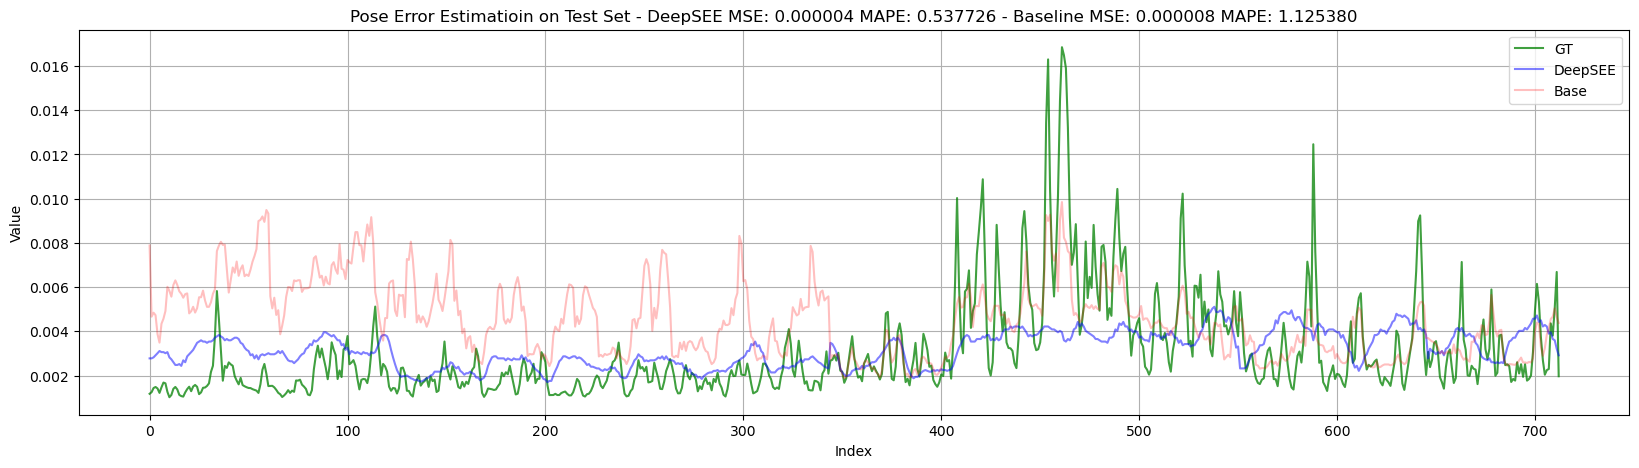

In [83]:
all_test_DeepSEE = []
all_test_base = []
all_test_gt = []
#finetune_split_config_list = finetune_split_config_list
for idx, finetune_split_config in enumerate(finetune_split_config_list):
    # Load cross-validation assignment
    sup_finetune_train_data = assign_traj(slam_data, finetune_split_config["sup_finetune_train_traj"])
    sup_finetune_val_data = assign_traj(slam_data, finetune_split_config["sup_finetune_val_traj"])
    sup_finetune_test_data = assign_traj(slam_data, finetune_split_config["sup_finetune_test_traj"])

    # Load dataset
    sup_finetune_train_set = SLAMDataset(sup_finetune_train_data, augment=False, onlyOneIter=False, lower=lower_bound, upper=upper_bound, std=std)
    sup_finetune_val_set = SLAMDataset(sup_finetune_val_data, augment=False, onlyOneIter=False, lower=lower_bound, upper=upper_bound, std=std)
    sup_finetune_test_set = SLAMDataset(sup_finetune_test_data, augment=False, onlyOneIter=True, lower=lower_bound, upper=upper_bound, std=std)

    # Use dataset loader
    train_loader = DataLoader(sup_finetune_train_set, **train_params)
    val_loader = DataLoader(sup_finetune_val_set, **val_params)
    test_loader = DataLoader(sup_finetune_test_set, **test_params)

    # Run baseline
    sup_finetune_train_data_baseline = MergeDict(sup_finetune_train_data, sup_pretrain_train_data)
    sup_finetune_train_set_baseline = SLAMDataset(sup_finetune_train_data_baseline, augment=False, onlyOneIter=False, lower=lower_bound, upper=upper_bound, std=std)
    
    XT_train, YT_train, XT_val, YT_val, XT_test, YT_test = ensemble_tree_data_loader(sup_finetune_train_set_baseline, sup_finetune_val_set, sup_finetune_test_set)
    regr = RandomForestRegressor(n_estimators=25, max_features='sqrt', min_samples_split=2, min_samples_leaf=2, bootstrap=False, 
                        max_depth=10, random_state=0, n_jobs=-1)
    regr.fit(XT_train, YT_train)
    YT_test_head = regr.predict(XT_test)


    # DeepSEE training
    # load the best pretrained model checkpoint
    best_model_cp = torch.load('{}/SupervisedPretrain_best_model.pth'.format(writer.get_logdir()), weights_only=False)
    best_model_epoch = best_model_cp['epoch']
    model.load_state_dict(best_model_cp['model_state_dict'])
    print(f"load the best pretrained model\n")
    finetune_config = copy.deepcopy(config)
    finetune_config.lr = config.lr
    finetune_config.epochs = 10

    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze the last few layers 
    for param in model.ca_regressor.fc1.parameters():
        param.requires_grad = True
    for param in model.ca_regressor.fc2.parameters():
        param.requires_grad = True

    model = train_with_validation(model, train_loader, val_loader, test_loader, finetune_config, mode=f"SupervisedFinetune_{idx}")

    # Evaluation the DeepSEE model
    # load the best model checkpoint
    best_model_cp = torch.load('{}/SupervisedFinetune_{}_best_model.pth'.format(writer.get_logdir(), idx), weights_only=False)

    best_model_epoch = best_model_cp['epoch']
    model.load_state_dict(best_model_cp['model_state_dict'])
    print(f"Best Supervised Finetuned model was saved at {best_model_epoch} epochs\n")

    SuperviseFinetune_Y_gt, SuperviseFinetune_Y_est, _ = evaluate_on_test(model, test_loader, mode=f"SupervisedFinetune_{idx}")

    plot_result_on_testset(SuperviseFinetune_Y_gt, SuperviseFinetune_Y_est, YT_test_head , mode=f"SupervisedFinetune_{idx}")

    if config.target_transform:
        plot_result_on_testset(SuperviseFinetune_Y_gt, SuperviseFinetune_Y_est, YT_test_head , mode=f"SupervisedFinetune_{idx}", target_transform=config.target_transform)
    
    all_test_gt.append(SuperviseFinetune_Y_gt)
    all_test_DeepSEE.append(SuperviseFinetune_Y_est)
    all_test_base.append(YT_test_head)

In [84]:
def get_rmse(y_gt,y_est):
    return np.sqrt(np.mean((y_gt - y_est) ** 2))

In [87]:
def get_all_numpy_array(test_tensor_list):
    y_list = [torch.concat(tensor_list) for tensor_list in test_tensor_list]
    y_array = torch.concat(y_list).cpu().numpy()
    y_array = (np.exp(y_array)-1)/10000
    return y_array

def get_each_numpy_array(test_tensor_list):
    y_array_list = [torch.concat(tensor_list).cpu().numpy() for tensor_list in test_tensor_list]
    y_array_list = [(np.exp(y_array)-1)/10000 for y_array in y_array_list]
    return y_array_list  # EuRoC EWR/Lead Time 결과랑 합쳐서 논문 쓰는 게 현실적


In [88]:
test_base = np.concatenate(all_test_base)
test_base = (np.exp(test_base)-1)/10000
test_base = np.expand_dims(test_base, axis=1)
test_DeepSEE = get_all_numpy_array(all_test_DeepSEE)
test_gt = get_all_numpy_array(all_test_gt)

In [89]:
test_base_list = [np.expand_dims((np.exp(y_array)-1)/10000, axis=1) for y_array in all_test_base]
test_DeepSEE_list = get_each_numpy_array(all_test_DeepSEE)
test_gt_list = get_each_numpy_array(all_test_gt)

In [90]:
test_base_list[0].shape

(1015, 1)

In [91]:
for i in range(len(test_gt_list)):
    print(f"Round{i} \t| RMSE \t | MAPE")
    print(f"Base \t| {get_rmse(test_gt_list[i], test_base_list[i])} |  {get_mape(test_gt_list[i], test_base_list[i])}")
    print(f"DeepSEE | {get_rmse(test_gt_list[i], test_DeepSEE_list[i])} |  {get_mape(test_gt_list[i], test_DeepSEE_list[i])}")

    print("="*50)

Round0 	| RMSE 	 | MAPE
Base 	| 0.0038846740211311475 |  0.9934229291070589
DeepSEE | 0.003790829563513398 |  0.42228415608406067
Round1 	| RMSE 	 | MAPE
Base 	| 0.0034745048154956972 |  1.0648842481768697
DeepSEE | 0.002508416771888733 |  0.5114794969558716
Round2 	| RMSE 	 | MAPE
Base 	| 0.003149610153749733 |  0.878792835904848
DeepSEE | 0.0036908057518303394 |  0.4455276131629944
Round3 	| RMSE 	 | MAPE
Base 	| 0.003963486447969056 |  1.1533321979101323
DeepSEE | 0.004102527163922787 |  0.4358883798122406
Round4 	| RMSE 	 | MAPE
Base 	| 0.004097595175305344 |  1.587749825062161
DeepSEE | 0.004003776703029871 |  0.5277306437492371
Round5 	| RMSE 	 | MAPE
Base 	| 0.0028289624772070946 |  1.1253799298392033
DeepSEE | 0.0020458288490772247 |  0.5377256274223328


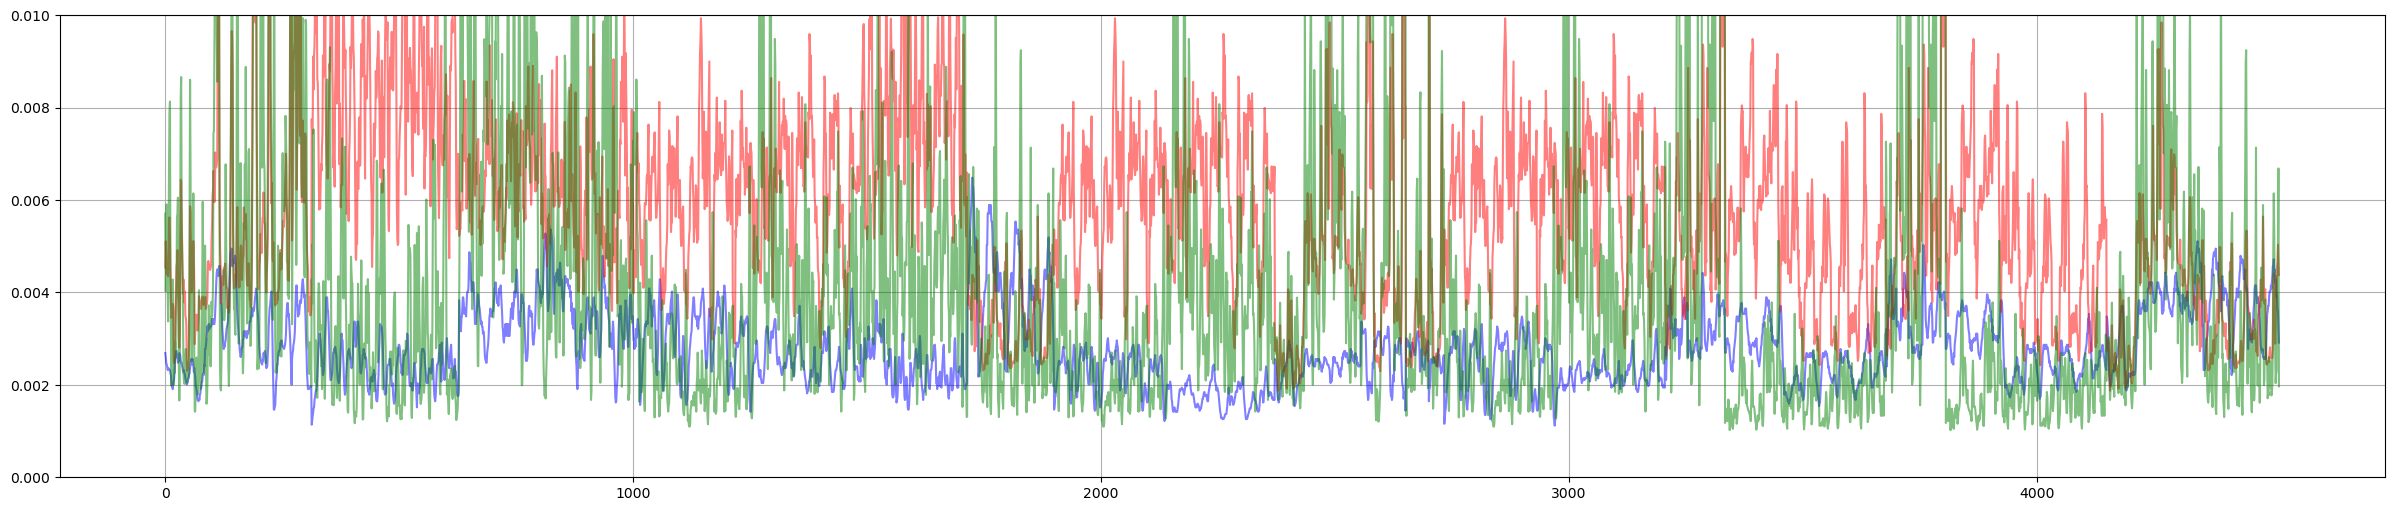

In [92]:
plt.figure(figsize=(30,6))
plt.plot(test_DeepSEE[:], c="b", alpha=0.5)
plt.plot(test_base[:], c='r', alpha=0.5)
plt.plot(test_gt, c='g', alpha=0.5)
plt.ylim(0, 0.01)
plt.grid()
plt.show()

In [93]:
print(get_rmse(test_gt, test_DeepSEE))
print(get_rmse(test_gt, test_base))

0.003397544
0.0035618320866168934


In [94]:
print(get_mape(test_gt, test_DeepSEE))
print(get_mape(test_gt, test_base))

0.47507593035697937
1.090390171271434


In [95]:
torch.save(model.state_dict(), writer.get_logdir() + "/test_model.pth")

In [96]:
model

DeepSEEModel(
  (pd_encoder): TimesformerModel(
    (embeddings): TimesformerEmbeddings(
      (patch_embeddings): TimesformerPatchEmbeddings(
        (projection): Conv2d(3, 192, kernel_size=(8, 8), stride=(8, 8))
      )
      (pos_drop): Dropout(p=0, inplace=False)
      (time_drop): Dropout(p=0, inplace=False)
    )
    (encoder): TimesformerEncoder(
      (layer): ModuleList(
        (0-2): 3 x TimesformerLayer(
          (drop_path): Identity()
          (attention): TimeSformerAttention(
            (attention): TimesformerSelfAttention(
              (qkv): Linear(in_features=192, out_features=576, bias=True)
              (attn_drop): Dropout(p=0.0, inplace=False)
            )
            (output): TimesformerSelfOutput(
              (dense): Linear(in_features=192, out_features=192, bias=True)
              (dropout): Dropout(p=0, inplace=False)
            )
          )
          (intermediate): TimesformerIntermediate(
            (dense): Linear(in_features=192, out_feat

In [97]:
# EuRoC 데이터 로드
euroc_data = DeepSEEData(root_dir=config.data_dir,
                         dataset_list=["EuRoC"],
                         n_proc=config.n_proc,
                         config=config)
slam_data.data["EuRoC"] = euroc_data.data["EuRoC"]
print("EuRoC loaded:", list(slam_data.data["EuRoC"].keys()))

Loading DeepSEE-EuRoC dataset
EuRoC loaded: ['MH_01_easy', 'MH_02_easy', 'MH_03_medium', 'MH_04_difficult', 'MH_05_difficult', 'V1_01_easy', 'V1_02_medium', 'V1_03_difficult', 'V2_01_easy', 'V2_02_medium', 'V2_03_difficult']


In [98]:
# EuRoC 5-fold cross-validation (MH_01~05, 각각 1개씩 test)
euroc_finetune_config_list = [
    {"sup_finetune_train_traj": {"EuRoC": ["MH_02_easy","MH_03_medium","MH_04_difficult","MH_05_difficult"]},
     "sup_finetune_val_traj":   {"EuRoC": ["MH_01_easy"]},
     "sup_finetune_test_traj":  {"EuRoC": ["MH_01_easy"]}},
    {"sup_finetune_train_traj": {"EuRoC": ["MH_01_easy","MH_03_medium","MH_04_difficult","MH_05_difficult"]},
     "sup_finetune_val_traj":   {"EuRoC": ["MH_02_easy"]},
     "sup_finetune_test_traj":  {"EuRoC": ["MH_02_easy"]}},
    {"sup_finetune_train_traj": {"EuRoC": ["MH_01_easy","MH_02_easy","MH_04_difficult","MH_05_difficult"]},
     "sup_finetune_val_traj":   {"EuRoC": ["MH_03_medium"]},
     "sup_finetune_test_traj":  {"EuRoC": ["MH_03_medium"]}},
    {"sup_finetune_train_traj": {"EuRoC": ["MH_01_easy","MH_02_easy","MH_03_medium","MH_05_difficult"]},
     "sup_finetune_val_traj":   {"EuRoC": ["MH_04_difficult"]},
     "sup_finetune_test_traj":  {"EuRoC": ["MH_04_difficult"]}},
    {"sup_finetune_train_traj": {"EuRoC": ["MH_01_easy","MH_02_easy","MH_03_medium","MH_04_difficult"]},
     "sup_finetune_val_traj":   {"EuRoC": ["MH_05_difficult"]},
     "sup_finetune_test_traj":  {"EuRoC": ["MH_05_difficult"]}},
]

/home/junhyun/miniconda3/envs/deepsee/lib/python3.9/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


  0%|          | 0/680 [00:00<?, ?it/s]


Best validation loss: 6.462933928878219

Saving best model for epoch: 2


Best validation loss: 4.363361588230839

Saving best model for epoch: 3


Best validation loss: 2.6501552352198847

Saving best model for epoch: 4


Best validation loss: 1.4740582218876592

Saving best model for epoch: 5


Best validation loss: 0.8086722162034776

Saving best model for epoch: 6


Best validation loss: 0.5513755646016862

Saving best model for epoch: 7


Best validation loss: 0.5034218507784384

Saving best model for epoch: 8

Saving final model...
EuRoC Fold 0 best model loaded
Loss value on test set: 0.46561217308044434


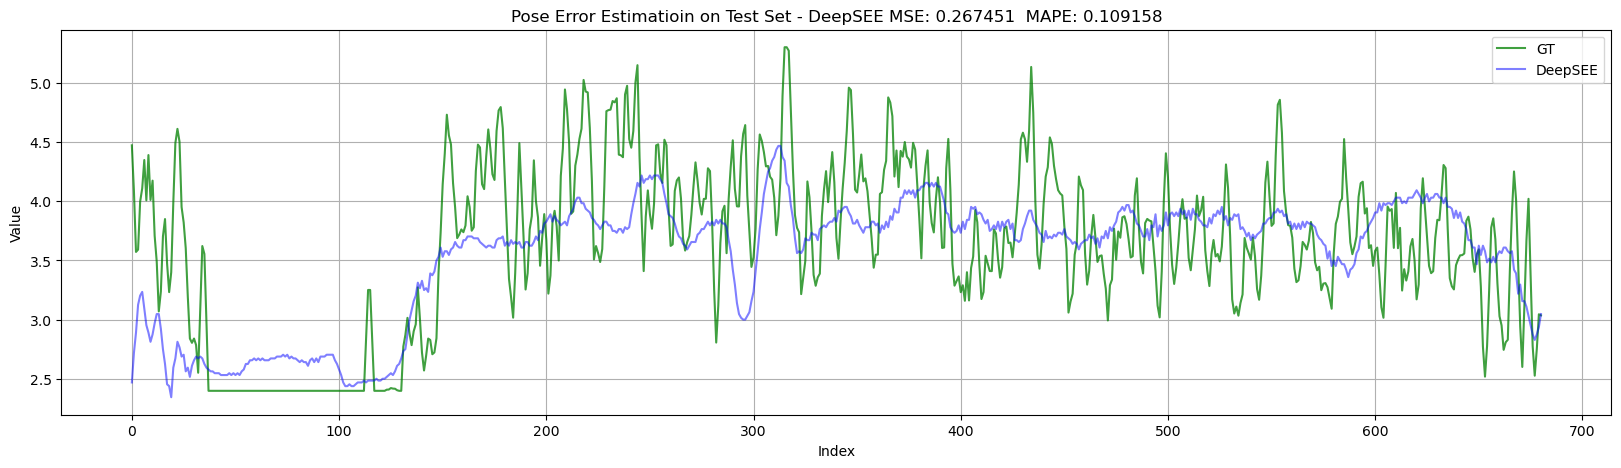

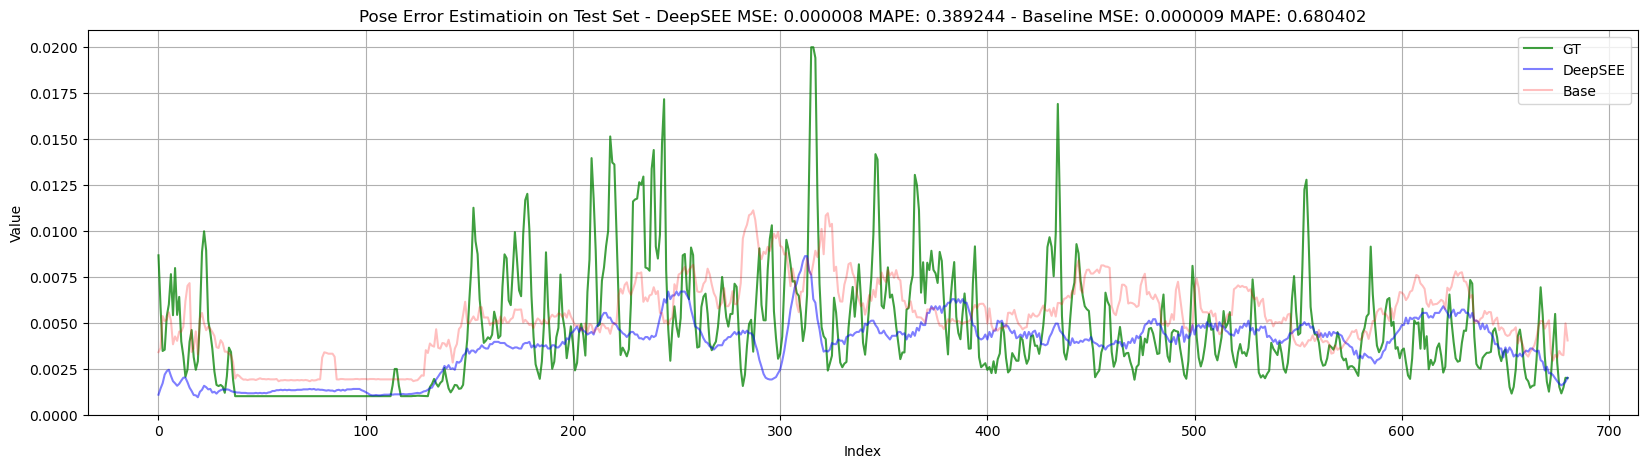

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

In [99]:
# EuRoC finetune & evaluation
all_test_DeepSEE_euroc = []
all_test_base_euroc = []
all_test_gt_euroc = []

for idx, finetune_split_config in enumerate(euroc_finetune_config_list):
    sup_finetune_train_data = assign_traj(slam_data, finetune_split_config["sup_finetune_train_traj"])
    sup_finetune_val_data   = assign_traj(slam_data, finetune_split_config["sup_finetune_val_traj"])
    sup_finetune_test_data  = assign_traj(slam_data, finetune_split_config["sup_finetune_test_traj"])

    sup_finetune_train_set = SLAMDataset(sup_finetune_train_data, augment=False, onlyOneIter=False, lower=lower_bound, upper=upper_bound, std=std)
    sup_finetune_val_set   = SLAMDataset(sup_finetune_val_data,   augment=False, onlyOneIter=False, lower=lower_bound, upper=upper_bound, std=std)
    sup_finetune_test_set  = SLAMDataset(sup_finetune_test_data,  augment=False, onlyOneIter=True,  lower=lower_bound, upper=upper_bound, std=std)

    train_loader = DataLoader(sup_finetune_train_set, **train_params)
    val_loader   = DataLoader(sup_finetune_val_set,   **val_params)
    test_loader  = DataLoader(sup_finetune_test_set,  **test_params)

    # Baseline
    sup_finetune_train_data_baseline = MergeDict(sup_finetune_train_data, sup_pretrain_train_data)
    sup_finetune_train_set_baseline  = SLAMDataset(sup_finetune_train_data_baseline, augment=False, onlyOneIter=False, lower=lower_bound, upper=upper_bound, std=std)
    XT_train, YT_train, XT_val, YT_val, XT_test, YT_test = ensemble_tree_data_loader(sup_finetune_train_set_baseline, sup_finetune_val_set, sup_finetune_test_set)
    regr = RandomForestRegressor(n_estimators=25, max_features='sqrt', min_samples_split=2, min_samples_leaf=2,
                                 bootstrap=False, max_depth=10, random_state=0, n_jobs=-1)
    regr.fit(XT_train, YT_train)
    YT_test_head = regr.predict(XT_test)

    # DeepSEE finetune
    best_model_cp = torch.load('{}/SupervisedPretrain_best_model.pth'.format(writer.get_logdir()), weights_only=False)
    model.load_state_dict(best_model_cp['model_state_dict'])

    finetune_config = copy.deepcopy(config)
    finetune_config.epochs = 10

    for param in model.parameters():
        param.requires_grad = False
    for param in model.ca_regressor.fc1.parameters():
        param.requires_grad = True
    for param in model.ca_regressor.fc2.parameters():
        param.requires_grad = True

    model = train_with_validation(model, train_loader, val_loader, test_loader,
                                  finetune_config, mode=f"EuRoC_Finetune_{idx}")

    best_model_cp = torch.load('{}/EuRoC_Finetune_{}_best_model.pth'.format(writer.get_logdir(), idx), weights_only=False)
    model.load_state_dict(best_model_cp['model_state_dict'])
    print(f"EuRoC Fold {idx} best model loaded")

    Y_gt, Y_est, _ = evaluate_on_test(model, test_loader, mode=f"EuRoC_Finetune_{idx}")
    plot_result_on_testset(Y_gt, Y_est, YT_test_head, mode=f"EuRoC_Finetune_{idx}", target_transform=config.target_transform)

    all_test_gt_euroc.append(Y_gt)
    all_test_DeepSEE_euroc.append(Y_est)
    all_test_base_euroc.append(YT_test_head)

    # hds_v1.py용 .npy 저장 (fold_idx와 sequence 순서 맞춤)
    import numpy as np
    np.save('{}/SupervisedFinetune_{}_Y_gt.npy'.format(writer.get_logdir(), idx),   Y_gt,         allow_pickle=True)
    np.save('{}/SupervisedFinetune_{}_Y_est.npy'.format(writer.get_logdir(), idx),  Y_est,        allow_pickle=True)
    np.save('{}/SupervisedFinetune_{}_Y_base.npy'.format(writer.get_logdir(), idx), YT_test_head, allow_pickle=True)
    print(f"Saved .npy for fold {idx}")

Apr07 SenseTime model loaded (zero-shot)


/home/junhyun/miniconda3/envs/deepsee/lib/python3.9/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Loss value on test set: 8.913436889648438


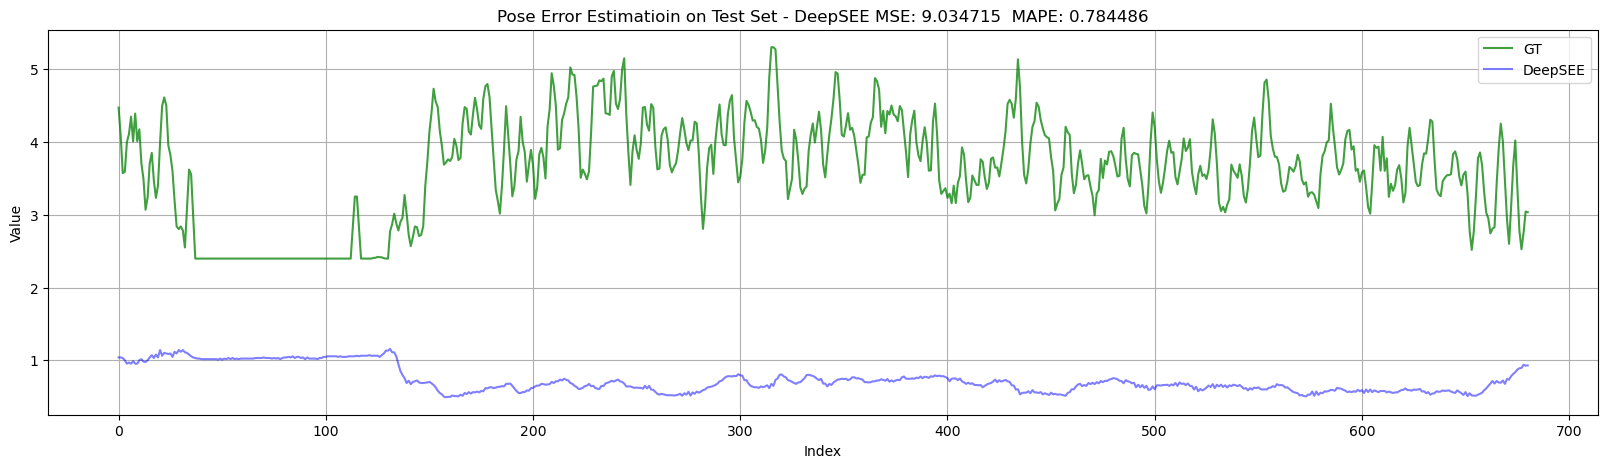

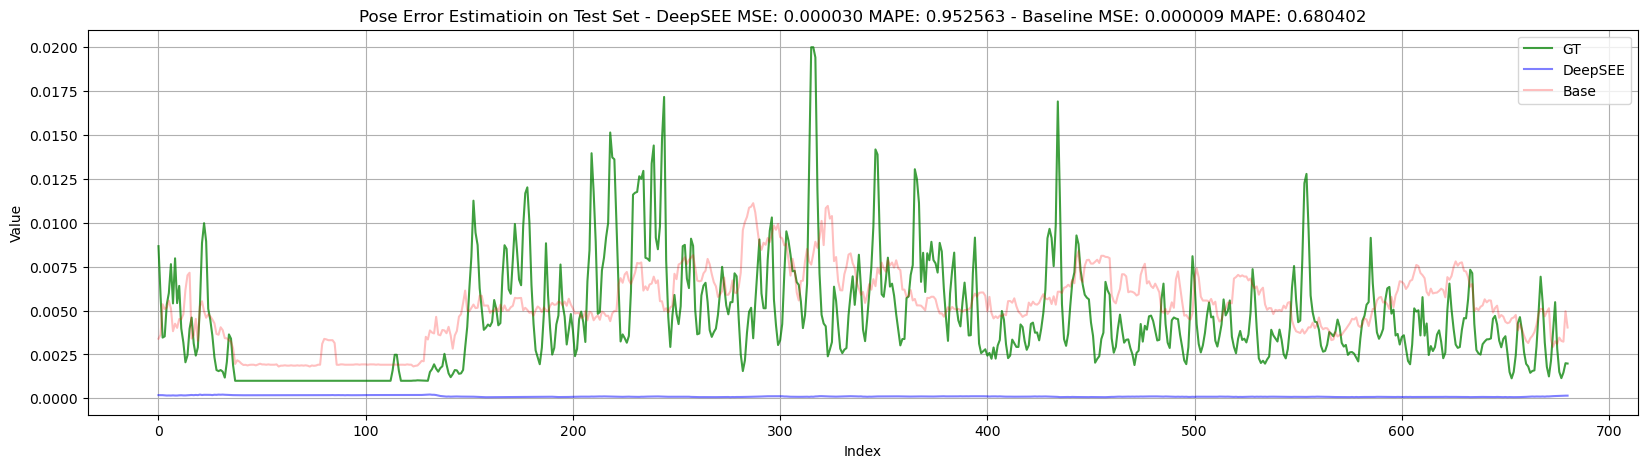

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

In [100]:
# Apr07 SenseTime 모델로 EuRoC zero-shot 추론 (finetune 없이)
import numpy as np

APR07_DIR = "/home/junhyun/SEESys/DeepSEE/Training/runs/Apr07_13-17-22_AHRI-Junhyun"

# Apr07 SenseTime pretrain 모델 로드 (EuRoC finetune 없이)
best_model_cp = torch.load(f'{APR07_DIR}/SupervisedPretrain_best_model.pth', weights_only=False)
model.load_state_dict(best_model_cp['model_state_dict'])
model.eval()
print("Apr07 SenseTime model loaded (zero-shot)")

for idx, finetune_split_config in enumerate(euroc_finetune_config_list):
    sup_finetune_train_data = assign_traj(slam_data, finetune_split_config["sup_finetune_train_traj"])
    sup_finetune_val_data   = assign_traj(slam_data, finetune_split_config["sup_finetune_val_traj"])
    sup_finetune_test_data  = assign_traj(slam_data, finetune_split_config["sup_finetune_test_traj"])

    sup_finetune_test_set = SLAMDataset(sup_finetune_test_data, augment=False, onlyOneIter=True,
                                        lower=lower_bound, upper=upper_bound, std=std)
    sup_finetune_val_set  = SLAMDataset(sup_finetune_val_data,  augment=False, onlyOneIter=False,
                                        lower=lower_bound, upper=upper_bound, std=std)
    test_loader = DataLoader(sup_finetune_test_set, **test_params)

    # Baseline (RF)
    sup_finetune_train_data_baseline = MergeDict(sup_finetune_train_data, sup_pretrain_train_data)
    sup_finetune_train_set_baseline  = SLAMDataset(sup_finetune_train_data_baseline, augment=False, onlyOneIter=False,
                                                    lower=lower_bound, upper=upper_bound, std=std)
    XT_train, YT_train, XT_val, YT_val, XT_test, YT_test = ensemble_tree_data_loader(
        sup_finetune_train_set_baseline, sup_finetune_val_set, sup_finetune_test_set)
    regr = RandomForestRegressor(n_estimators=25, max_features='sqrt', min_samples_split=2,
                                  min_samples_leaf=2, bootstrap=False, max_depth=10,
                                  random_state=0, n_jobs=-1)
    regr.fit(XT_train, YT_train)
    YT_test_head = regr.predict(XT_test)

    Y_gt, Y_est, _ = evaluate_on_test(model, test_loader, mode=f"EuRoC_ZeroShot_{idx}")
    plot_result_on_testset(Y_gt, Y_est, YT_test_head, mode=f"EuRoC_ZeroShot_{idx}",
                           target_transform=config.target_transform)

    np.save(f'{APR07_DIR}/SupervisedFinetune_{idx}_Y_gt.npy',   Y_gt,         allow_pickle=True)
    np.save(f'{APR07_DIR}/SupervisedFinetune_{idx}_Y_est.npy',  Y_est,        allow_pickle=True)
    np.save(f'{APR07_DIR}/SupervisedFinetune_{idx}_Y_base.npy', YT_test_head, allow_pickle=True)
    print(f"Saved zero-shot .npy for EuRoC fold {idx}")

print("Done. hds_v1.py RUN_DIR을 Apr07_13-17-22_AHRI-Junhyun 으로 바꾸면 됨")
